# Yhack Prediction Market Dashboard Lab

## 1. Problem Statement

This notebook follows an **asset-first trading architecture**.

We are **not** directly trading binary Polymarket contracts such as "Will Bitcoin reach price X?".
Instead:

- we trade the underlying crypto asset such as `BTC`, `ETH`, or `SOL`
- we use financial market data as the main trading engine
- we use Polymarket as an **information, confidence, and caution layer**
- Polymarket helps us decide whether to:
  - take the trade
  - reduce size
  - hold off
  - avoid entirely

## Goal

Build a research notebook that simulates crypto trading decisions using:

1. **underlying market data** for direction and trade setup
2. **relevant Polymarket questions** for confirmation and risk context
3. a **fusion layer** that converts technical strength and prediction-market context into:
   - confidence score
   - caution zone
   - position size recommendation

## Architecture Order

This notebook is implemented in the exact agreed order:

1. Problem statement
2. Inputs
3. Underlying market data
4. Polymarket data pull
5. Question tagging
6. Polymarket aggregation
7. Fusion logic
8. Decision dashboard
9. Scenario analysis
10. Backtest comparison


## 2. Inputs

These inputs control the asset-first experiment. The traded object is the crypto asset, while Polymarket markets are pulled and summarized as supporting evidence.


In [1]:
import json
import os
import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None
import yfinance as yf
from IPython.display import display

# CHANGED HERE: make notebook robust when seaborn is unavailable in the local kernel.
if sns is not None:
    sns.set_theme(style='whitegrid', context='talk')
else:
    plt.style.use('ggplot')

for candidate in [Path.cwd(), Path.cwd() / 'Yhack']:
    candidate_str = str(candidate.resolve())
    if candidate.exists() and candidate_str not in sys.path:
        sys.path.append(candidate_str)

from polymarket_config import get_polymarket_config, redacted_polymarket_config

try:
    from py_clob_client.client import ClobClient
except Exception:
    ClobClient = None

asset = 'BTC-USD'
asset_label = 'BTC'
benchmark_asset = 'SPY'
# CHANGED HERE: switch to a 2-year daily window for a longer backtest horizon.
end_date = str(pd.Timestamp.today().normalize().date())
start_date = str((pd.Timestamp.today().normalize() - pd.Timedelta(days=730)).date())
interval = '1d'
market_data_mode = 'auto'

# CHANGED HERE: resolve the secrets file correctly whether the notebook is opened from repo root or from the Yhack folder.
polymarket_env_path = Path.cwd() / 'Yhack' / '.env' if (Path.cwd() / 'Yhack' / '.env').exists() else Path.cwd() / '.env'
polymarket_use_live = True
polymarket_market_limit = 120
# CHANGED HERE: keep Polymarket history on the same daily resolution as the asset trading frame.
polymarket_history_fidelity_minutes = 1440
polymarket_alignment_freq = '1d'
polymarket_search_terms = {
    'BTC': ['bitcoin', 'btc', 'crypto reserve', 'bitcoin reserve', 'bitcoin etf'],
    'ETH': ['ethereum', 'eth', 'ether etf'],
    'SOL': ['solana', 'sol', 'sol etf'],
}
# CHANGED HERE: route crypto market candles to Kraken instead of relying on Yahoo Finance for intraday crypto data.
kraken_pair_map = {
    'BTC-USD': 'BTC/USD',
    'ETH-USD': 'ETH/USD',
    'SOL-USD': 'SOL/USD',
}

technical_long_threshold = 0.25
technical_short_threshold = -0.25
pm_confirmation_threshold = 0.05
confidence_trade_threshold = 35
avoid_threshold = 75
subjective_prob_buffer = 0.05

polymarket_config = get_polymarket_config(polymarket_env_path)
print({'asset': asset, 'asset_label': asset_label, 'benchmark_asset': benchmark_asset, 'start_date': start_date, 'end_date': end_date, 'interval': interval, 'market_data_mode': market_data_mode})
print(redacted_polymarket_config(polymarket_env_path))


{'asset': 'BTC-USD', 'asset_label': 'BTC', 'benchmark_asset': 'SPY', 'start_date': '2024-03-28', 'end_date': '2026-03-28', 'interval': '1d', 'market_data_mode': 'auto'}
{'env_path': '/Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/Yhack/.env', 'gamma_host': 'https://gamma-api.polymarket.com', 'clob_host': 'https://clob.polymarket.com', 'data_host': 'https://data-api.polymarket.com', 'request_timeout': 20, 'chain_id': 137, 'has_private_key': False, 'has_proxy_address': False, 'has_api_key': True, 'has_secret': True, 'has_passphrase': True}


## 3. Underlying Market Data

This section is the main trading engine. It uses normal financial market data for the selected crypto asset and produces the base technical signal.


Market source: Yahoo Finance


Price,Close,Return_1D,RSI,MACD_Hist,Volatility_20D,Drawdown,TechnicalScore,BaseDirection,TechnicalConfidence
Date,,,,,,,,,
2026-03-16,74861.085938,0.028454,64.819456,940.753916,0.452071,-0.399923,8.000000e-01,Long,8.000000e+01
2026-03-17,73922.476562,-0.012538,63.409864,924.019739,0.414714,-0.407447,7.000000e-01,Long,7.000000e+01
2026-03-18,71245.578125,-0.036212,46.194333,696.218340,0.438173,-0.428905,7.000000e-01,Long,7.000000e+01
2026-03-19,69912.789062,-0.018707,47.519270,432.256920,0.434736,-0.439588,2.775558e-17,Flat,2.775558e-15
2026-03-20,70522.585938,0.008722,57.180062,282.454489,0.432273,-0.434700,7.000000e-01,Long,7.000000e+01
2026-03-21,68711.523438,-0.025681,54.096417,56.920229,0.437631,-0.449217,2.775558e-17,Flat,2.775558e-15
2026-03-22,67845.210938,-0.012608,55.475140,-144.096388,0.409591,-0.456162,-7.000000e-01,Short,7.000000e+01
2026-03-23,70914.859375,0.045245,57.071893,-67.695944,0.438477,-0.431556,2.000000e-01,Flat,2.000000e+01
2026-03-24,70517.859375,-0.005598,51.776050,-42.500008,0.375376,-0.434738,-2.775558e-17,Flat,2.775558e-15


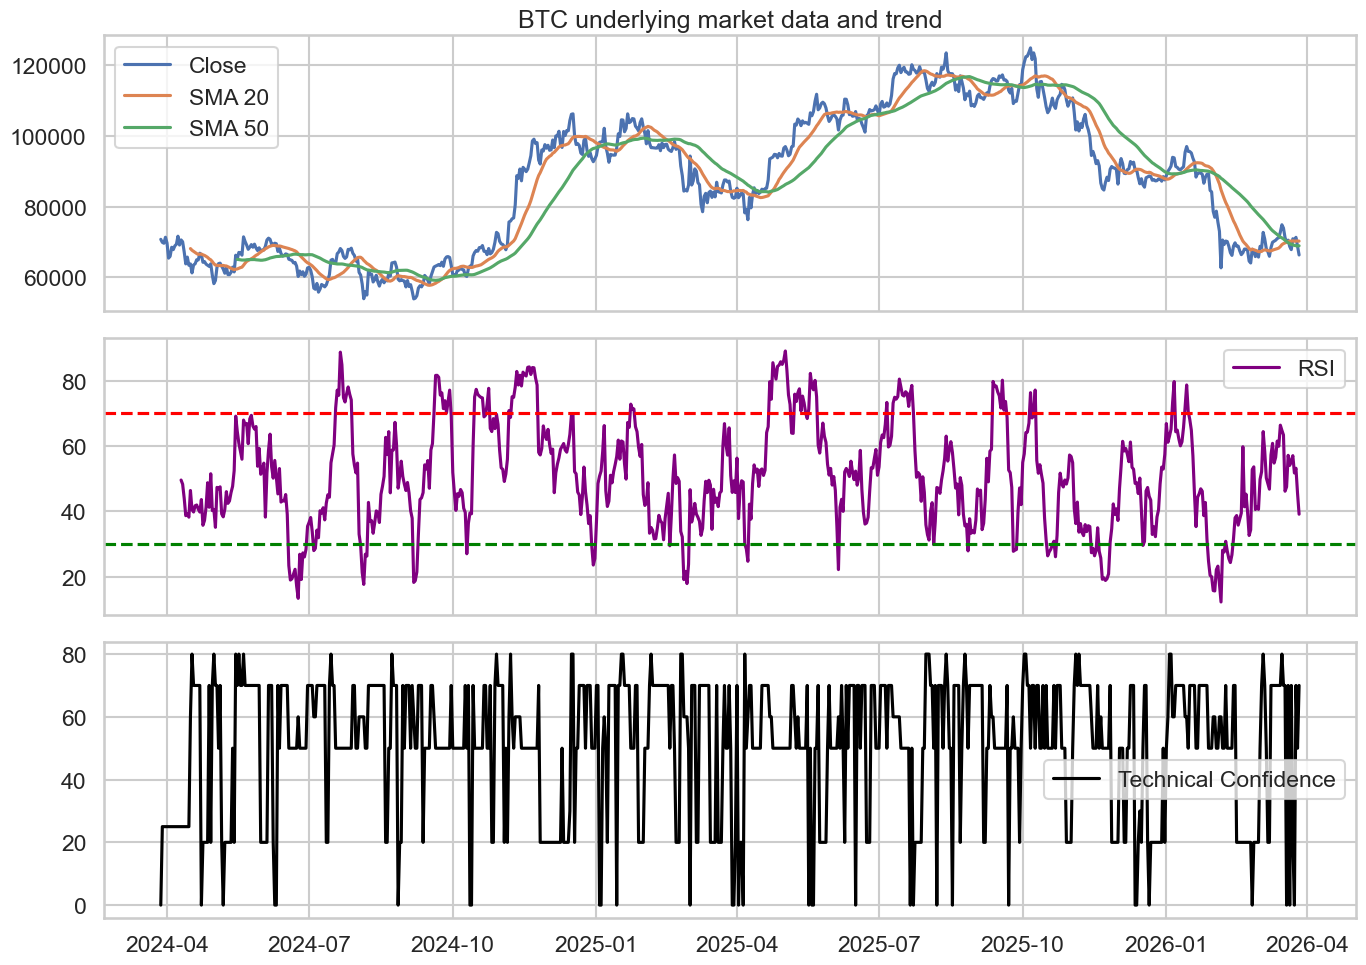

In [2]:
def generate_synthetic_data(ticker, start_date, end_date, interval):
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)
    # CHANGED HERE: use lowercase 'h' to avoid the pandas deprecation warning for hourly synthetic fallback indices.
    freq_map = {'1h': 'h', '1d': 'B', '1wk': 'W-FRI', '1mo': 'MS', '1y': 'YS'}
    freq = freq_map.get(interval, 'B')
    idx = pd.date_range(start_ts, end_ts, freq=freq)
    if len(idx) < 120:
        idx = pd.date_range(start_ts, periods=220, freq='B')

    seed = sum(ord(ch) for ch in ticker) % (2**32 - 1)
    rng = np.random.default_rng(seed)
    drift = 0.0005 + (seed % 13) / 100000
    vol = 0.018 + (seed % 9) / 1000
    shocks = rng.normal(drift, vol, len(idx))
    close = 100 * np.exp(np.cumsum(shocks))
    open_ = np.concatenate([[close[0]], close[:-1]]) * (1 + rng.normal(0, 0.003, len(idx)))
    high = np.maximum(open_, close) * (1 + rng.uniform(0.001, 0.018, len(idx)))
    low = np.minimum(open_, close) * (1 - rng.uniform(0.001, 0.018, len(idx)))
    volume = rng.integers(1_000_000, 8_000_000, len(idx))
    synthetic = pd.DataFrame({'Open': open_, 'High': high, 'Low': low, 'Close': close, 'Adj Close': close, 'Volume': volume}, index=idx)
    synthetic.index.name = 'Date'
    return synthetic


# CHANGED HERE: keep Kraken available as the crypto OHLC fallback, especially when Yahoo intraday requests fail.
def get_kraken_market_data(ticker, start_date, end_date, interval):
    pair = kraken_pair_map.get(ticker)
    interval_map = {'1h': 60, '1d': 1440}
    if pair is None or interval not in interval_map:
        return pd.DataFrame()
    params = {
        'pair': pair,
        'interval': interval_map[interval],
        'since': int(pd.Timestamp(start_date).tz_localize('UTC').timestamp()),
    }
    response = requests.get('https://api.kraken.com/0/public/OHLC', params=params, timeout=10)
    response.raise_for_status()
    payload = response.json()
    if payload.get('error'):
        raise ValueError(f"Kraken OHLC error: {payload['error']}")
    result = payload.get('result', {})
    pair_key = next((key for key in result.keys() if key != 'last'), None)
    rows = result.get(pair_key, []) if pair_key else []
    if not rows:
        return pd.DataFrame()
    frame = pd.DataFrame(rows, columns=['time', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Volume', 'Count'])
    frame['Date'] = pd.to_datetime(frame['time'], unit='s', utc=True).dt.tz_localize(None)
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'VWAP', 'Volume', 'Count']
    for col in numeric_cols:
        frame[col] = pd.to_numeric(frame[col], errors='coerce')
    frame = frame.set_index('Date').sort_index()
    frame = frame.loc[(frame.index >= pd.to_datetime(start_date)) & (frame.index < pd.to_datetime(end_date) + pd.Timedelta(days=1))]
    frame.index.name = 'Date'
    return frame[['Open', 'High', 'Low', 'Close', 'Volume']]


def get_market_data(ticker, start_date, end_date, interval, data_mode='auto'):
    data = pd.DataFrame()
    source = 'Synthetic Fallback'
    if data_mode.lower() in {'auto', 'live'}:
        try:
            # CHANGED HERE: use Yahoo first for daily backtests so the notebook can cover a full 2-year window when available.
            if interval.endswith('m') or interval.endswith('h'):
                start_ts = pd.to_datetime(start_date)
                end_ts = pd.to_datetime(end_date)
                lookback_days = max((end_ts - start_ts).days, 1) + 1
                data = yf.download(ticker, period=f'{lookback_days}d', interval=interval, progress=False, auto_adjust=False, threads=False, timeout=6)
            else:
                data = yf.download(ticker, start=start_date, end=end_date, interval=interval, progress=False, auto_adjust=False, threads=False, timeout=6)
        except Exception:
            data = pd.DataFrame()
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    required_cols = {'Open', 'High', 'Low', 'Close'}
    if not data.empty and required_cols.issubset(set(data.columns)):
        source = 'Yahoo Finance'
        return data.sort_index(), source
    # CHANGED HERE: if Yahoo does not provide valid daily crypto data, fall back to Kraken for the most recent available candles.
    if ticker in kraken_pair_map and data_mode.lower() in {'auto', 'live'}:
        try:
            data = get_kraken_market_data(ticker, start_date, end_date, interval)
            if not data.empty:
                return data.sort_index(), 'Kraken'
        except Exception:
            data = pd.DataFrame()
    return generate_synthetic_data(ticker, start_date, end_date, interval).sort_index(), source


def build_feature_lab(data, rsi_window=14, fast_window=12, slow_window=26, trend_window=20, long_trend_window=50, vol_window=20):
    df = data.copy()
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume'] if 'Volume' in df.columns else pd.Series(index=df.index, dtype=float)

    df['Return_1D'] = close.pct_change()
    df['Return_5D'] = close.pct_change(5)
    df['Return_20D'] = close.pct_change(20)
    df['LogReturn'] = np.log(close / close.shift(1))
    df['SMA_20'] = close.rolling(trend_window).mean()
    df['SMA_50'] = close.rolling(long_trend_window).mean()
    df['EMA_12'] = close.ewm(span=fast_window, adjust=False).mean()
    df['EMA_26'] = close.ewm(span=slow_window, adjust=False).mean()
    df['Momentum_20'] = close / close.shift(20) - 1

    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=rsi_window).mean()
    avg_loss = loss.rolling(window=rsi_window).mean().replace(0, 1e-10)
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    rolling_mean = close.rolling(trend_window).mean()
    rolling_std = close.rolling(trend_window).std()
    df['BB_Upper'] = rolling_mean + 2 * rolling_std
    df['BB_Lower'] = rolling_mean - 2 * rolling_std
    df['BB_Z'] = (close - rolling_mean) / rolling_std.replace(0, np.nan)
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / rolling_mean.replace(0, np.nan)

    true_range = pd.concat([high - low, (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    df['ATR_14'] = true_range.rolling(14).mean()
    df['RangePct'] = (high - low) / close.replace(0, np.nan)
    df['Volatility_20D'] = df['LogReturn'].rolling(vol_window).std() * np.sqrt(252)
    df['Drawdown'] = close / close.cummax() - 1
    df['Volume_Z'] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std().replace(0, np.nan)

    df['RSI_Signal'] = np.select([df['RSI'] < 30, df['RSI'] > 70], [1, -1], default=0)
    df['Trend_Signal'] = np.select([close > df['SMA_20'], close < df['SMA_20']], [1, -1], default=0)
    df['MACD_Signal_Flag'] = np.select([df['MACD_Hist'] > 0, df['MACD_Hist'] < 0], [1, -1], default=0)
    df['Breakout_Signal'] = np.select([close > df['BB_Upper'], close < df['BB_Lower']], [1, -1], default=0)

    df['TechnicalScore'] = (
        0.35 * df['Trend_Signal']
        + 0.25 * df['MACD_Signal_Flag']
        + 0.20 * df['RSI_Signal']
        + 0.10 * df['Breakout_Signal']
        + 0.10 * np.sign(df['Momentum_20'].fillna(0))
    )
    df['BaseDirection'] = np.select([df['TechnicalScore'] >= technical_long_threshold, df['TechnicalScore'] <= technical_short_threshold], ['Long', 'Short'], default='Flat')
    df['TechnicalConfidence'] = 100 * np.clip(df['TechnicalScore'].abs(), 0, 1)
    return df


market_data, market_source = get_market_data(asset, start_date, end_date, interval, market_data_mode)
feature_data = build_feature_lab(market_data)
print('Market source:', market_source)
display(feature_data[['Close', 'Return_1D', 'RSI', 'MACD_Hist', 'Volatility_20D', 'Drawdown', 'TechnicalScore', 'BaseDirection', 'TechnicalConfidence']].tail(12))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(feature_data.index, feature_data['Close'], label='Close')
axes[0].plot(feature_data.index, feature_data['SMA_20'], label='SMA 20')
axes[0].plot(feature_data.index, feature_data['SMA_50'], label='SMA 50')
axes[0].legend()
axes[0].set_title(f'{asset_label} underlying market data and trend')
axes[1].plot(feature_data.index, feature_data['RSI'], label='RSI', color='purple')
axes[1].axhline(30, linestyle='--', color='green')
axes[1].axhline(70, linestyle='--', color='red')
axes[1].legend()
axes[2].plot(feature_data.index, feature_data['TechnicalConfidence'], label='Technical Confidence', color='black')
axes[2].legend()
plt.tight_layout()
plt.show()


## 4. Polymarket Data Pull

This section fetches real Polymarket markets related to the selected asset. These markets are not traded directly. They are treated as event and sentiment inputs.


In [3]:
def parse_token_ids(raw_value):
    # CHANGED HERE: keep token parsing because historical price history is token-level.
    if raw_value is None or (isinstance(raw_value, float) and np.isnan(raw_value)):
        return []
    if isinstance(raw_value, list):
        return [str(x) for x in raw_value if str(x).strip()]
    if isinstance(raw_value, str):
        text = raw_value.strip()
        if not text:
            return []
        try:
            parsed = json.loads(text)
            if isinstance(parsed, list):
                return [str(x) for x in parsed if str(x).strip()]
        except Exception:
            pass
        if ',' in text:
            return [part.strip() for part in text.split(',') if part.strip()]
        return [text]
    return [str(raw_value)]


def safe_json_request(method, url, timeout=20, **kwargs):
    response = requests.request(method, url, timeout=timeout, **kwargs)
    response.raise_for_status()
    return response.json()


def fetch_gamma_markets(config, limit=100):
    params = {'limit': limit, 'active': 'true', 'closed': 'false'}
    data = safe_json_request('GET', f"{config['gamma_host'].rstrip('/')}/markets", params=params, timeout=config['request_timeout'])
    if isinstance(data, dict):
        data = data.get('markets', data.get('data', []))
    return pd.DataFrame(data)


def normalize_book_levels(levels):
    out = []
    for level in levels or []:
        price = getattr(level, 'price', None)
        size = getattr(level, 'size', None)
        if isinstance(level, dict):
            price = level.get('price', price)
            size = level.get('size', size)
        if price is not None:
            out.append({'price': float(price), 'size': float(size) if size is not None else np.nan})
    return out


def build_clob_client(config):
    if ClobClient is None:
        return None
    try:
        return ClobClient(config['clob_host'])
    except Exception:
        return None


def fetch_order_book_snapshot(token_id, config, client=None):
    if not token_id:
        return {'bids': [], 'asks': [], 'source': 'no_token'}
    if client is not None:
        try:
            book = client.get_order_book(token_id)
            return {'bids': normalize_book_levels(getattr(book, 'bids', [])), 'asks': normalize_book_levels(getattr(book, 'asks', [])), 'source': 'py_clob_client'}
        except Exception:
            pass

    host = config['clob_host'].rstrip('/')
    attempts = [
        ('GET', f'{host}/book', {'params': {'token_id': token_id}}),
        ('GET', f'{host}/book', {'params': {'asset_id': token_id}}),
        ('POST', f'{host}/books', {'json': {'token_ids': [token_id]}}),
    ]
    for method, url, kwargs in attempts:
        try:
            data = safe_json_request(method, url, timeout=config['request_timeout'], **kwargs)
            if isinstance(data, list):
                data = data[0] if data else {}
            if isinstance(data, dict) and 'data' in data and isinstance(data['data'], list):
                data = data['data'][0] if data['data'] else {}
            bids = normalize_book_levels(data.get('bids', []))
            asks = normalize_book_levels(data.get('asks', []))
            if bids or asks:
                return {'bids': bids, 'asks': asks, 'source': f'rest:{method}'}
        except Exception:
            continue
    return {'bids': [], 'asks': [], 'source': 'unavailable'}


def top_price(levels, side):
    if not levels:
        return np.nan
    prices = [level['price'] for level in levels if pd.notna(level['price'])]
    if not prices:
        return np.nan
    return max(prices) if side == 'bid' else min(prices)


def filter_markets_for_asset(markets, asset_label, search_terms):
    if markets.empty:
        return markets
    search_terms = [term.lower() for term in search_terms]
    question = markets.get('question', pd.Series('', index=markets.index)).astype(str).str.lower()
    slug = markets.get('slug', pd.Series('', index=markets.index)).astype(str).str.lower()
    desc = markets.get('description', pd.Series('', index=markets.index)).astype(str).str.lower()
    mask = pd.Series(False, index=markets.index)
    for term in search_terms:
        mask = mask | question.str.contains(term, na=False) | slug.str.contains(term, na=False) | desc.str.contains(term, na=False)
    return markets.loc[mask].copy().reset_index(drop=True)


def build_polymarket_market_board(asset_label, config, limit=120):
    search_terms = polymarket_search_terms.get(asset_label, [asset_label.lower()])
    all_markets = fetch_gamma_markets(config, limit=limit)
    relevant = filter_markets_for_asset(all_markets, asset_label, search_terms)
    if relevant.empty:
        return relevant

    client = build_clob_client(config)
    rows = []
    for _, row in relevant.iterrows():
        token_ids = []
        for candidate_key in ['clobTokenIds', 'tokenIds']:
            if candidate_key in row.index:
                token_ids = parse_token_ids(row[candidate_key])
                if token_ids:
                    break
        yes_token = token_ids[0] if token_ids else None
        book = fetch_order_book_snapshot(yes_token, config, client)
        best_bid = top_price(book['bids'], 'bid')
        best_ask = top_price(book['asks'], 'ask')
        mid = (best_bid + best_ask) / 2 if pd.notna(best_bid) and pd.notna(best_ask) else best_bid if pd.notna(best_bid) else best_ask

        rows.append({
            'market_id': row.get('conditionId', row.get('slug')),
            'slug': row.get('slug', ''),
            'question': row.get('question', row.get('title', '')),
            'description': row.get('description', ''),
            'yes_token_id': yes_token,
            'mid': mid,
            'best_bid': best_bid,
            'best_ask': best_ask,
            'spread': best_ask - best_bid if pd.notna(best_bid) and pd.notna(best_ask) else np.nan,
            'liquidity': pd.to_numeric(row.get('liquidity', row.get('liquidityNum', np.nan)), errors='coerce'),
            'volume': pd.to_numeric(row.get('volume', row.get('volumeNum', np.nan)), errors='coerce'),
            'end_date': row.get('endDate', row.get('resolutionDate')),
            'book_source': book['source'],
        })
    board = pd.DataFrame(rows)
    board['event_date'] = pd.to_datetime(board['end_date'], errors='coerce', utc=True).dt.tz_localize(None)
    board['days_to_resolution'] = (board['event_date'] - pd.Timestamp.today().normalize()).dt.days
    return board.sort_values(['liquidity', 'volume'], ascending=False, na_position='last').reset_index(drop=True)


# CHANGED HERE: fetch Polymarket history in supported chunks so the CLOB price-history endpoint can be used over a 14-day intraday window.
def fetch_token_price_history(token_id, config, start_date, end_date, fidelity_minutes=60, alignment_freq='1h', chunk_days=13):
    if not token_id:
        return pd.DataFrame(columns=['aligned_time', 'pm_price'])
    chunk_start = pd.Timestamp(start_date).tz_localize('UTC')
    chunk_end_limit = (pd.Timestamp(end_date) + pd.Timedelta(days=1)).tz_localize('UTC')
    history_frames = []
    while chunk_start < chunk_end_limit:
        chunk_end = min(chunk_start + pd.Timedelta(days=chunk_days), chunk_end_limit)
        params = {
            'market': token_id,
            'startTs': int(chunk_start.timestamp()),
            'endTs': int(chunk_end.timestamp()),
            'fidelity': fidelity_minutes,
        }
        try:
            data = safe_json_request('GET', f"{config['clob_host'].rstrip('/')}/prices-history", params=params, timeout=config['request_timeout'])
        except Exception:
            chunk_start = chunk_end
            continue
        frame = pd.DataFrame(data.get('history', []) if isinstance(data, dict) else [])
        if not frame.empty:
            frame['timestamp'] = pd.to_datetime(frame['t'], unit='s', utc=True).dt.tz_localize(None)
            frame['aligned_time'] = frame['timestamp'].dt.floor(alignment_freq)
            frame['pm_price'] = pd.to_numeric(frame['p'], errors='coerce')
            history_frames.append(frame[['aligned_time', 'pm_price']].dropna())
        chunk_start = chunk_end
    if not history_frames:
        return pd.DataFrame(columns=['aligned_time', 'pm_price'])
    history = pd.concat(history_frames, ignore_index=True)
    return history.drop_duplicates(subset=['aligned_time'], keep='last').sort_values('aligned_time').reset_index(drop=True)


polymarket_board = pd.DataFrame()
live_error = None
if polymarket_use_live:
    try:
        polymarket_board = build_polymarket_market_board(asset_label, polymarket_config, polymarket_market_limit)
    except Exception as exc:
        live_error = str(exc)

if live_error:
    print('Live Polymarket fetch error:', live_error)
if polymarket_board.empty:
    print('No live relevant Polymarket markets were available for this asset in this environment.')
else:
    display(polymarket_board[['slug', 'question', 'mid', 'spread', 'liquidity', 'volume', 'days_to_resolution', 'book_source']].head(20))


,slug,question,mid,spread,liquidity,volume,days_to_resolution,book_source
0,will-bitcoin-hit-1m-before-gta-vi-872,Will bitcoin hit $1m before GTA VI?,0.4885,0.003,420762.33793,3.799304e+06,125,rest:GET


## 5. Question Tagging

This section labels each relevant Polymarket question by direction and theme. This is rule-based in the first version so it stays transparent and easy to debug.


In [4]:
bullish_keywords = {
    'BTC': ['above', 'hit', 'reach', 'reserve', 'etf approval', 'approved', 'bull', 'all-time high', 'new high'],
    'ETH': ['above', 'hit', 'reach', 'etf approval', 'approved', 'bull', 'staking growth'],
    'SOL': ['above', 'hit', 'reach', 'etf approval', 'approved', 'bull'],
}

bearish_keywords = {
    'BTC': ['below', 'ban', 'collapse', 'hack', 'recession', 'crash', 'bear', 'down'],
    'ETH': ['below', 'ban', 'collapse', 'hack', 'bear', 'down'],
    'SOL': ['below', 'ban', 'collapse', 'hack', 'bear', 'down'],
}

theme_keywords = {
    'price': ['above', 'below', 'hit', 'reach', '$', 'price'],
    'regulation': ['sec', 'regulation', 'ban', 'approval', 'approved', 'reserve'],
    'macro': ['fed', 'rates', 'recession', 'inflation', 'treasury'],
    'adoption': ['etf', 'fund', 'treasury', 'reserve', 'adoption'],
    'risk': ['hack', 'collapse', 'bankruptcy', 'attack', 'outage'],
}


def score_relevance(text, asset_label):
    terms = polymarket_search_terms.get(asset_label, [asset_label.lower()])
    text = text.lower()
    score = 0
    for term in terms:
        if term.lower() in text:
            score += 1
    return score


def infer_theme(text):
    text = text.lower()
    scores = {theme: sum(keyword in text for keyword in keywords) for theme, keywords in theme_keywords.items()}
    best_theme = max(scores, key=scores.get) if scores else 'other'
    return best_theme if scores.get(best_theme, 0) > 0 else 'other'


def infer_direction(text, asset_label):
    text = text.lower()
    bull = sum(keyword in text for keyword in bullish_keywords.get(asset_label, []))
    bear = sum(keyword in text for keyword in bearish_keywords.get(asset_label, []))
    if bull > bear:
        return 'bullish'
    if bear > bull:
        return 'bearish'
    return 'ambiguous'


def tag_polymarket_questions(board, asset_label):
    if board.empty:
        return board
    tagged = board.copy()
    tagged['relevance_score'] = tagged['question'].astype(str).apply(lambda x: score_relevance(x, asset_label))
    tagged['theme'] = tagged['question'].astype(str).apply(infer_theme)
    tagged['direction'] = tagged['question'].astype(str).apply(lambda x: infer_direction(x, asset_label))
    tagged['direction_sign'] = tagged['direction'].map({'bullish': 1, 'bearish': -1, 'ambiguous': 0})
    tagged['market_quality_score'] = (
        0.45 * tagged['liquidity'].fillna(tagged['liquidity'].median()) / max(tagged['liquidity'].fillna(tagged['liquidity'].median()).max(), 1)
        + 0.35 * tagged['volume'].fillna(tagged['volume'].median()) / max(tagged['volume'].fillna(tagged['volume'].median()).max(), 1)
        + 0.20 * (1 - tagged['spread'].fillna(tagged['spread'].median()) / max(tagged['spread'].fillna(tagged['spread'].median()).max(), 1e-6))
    )
    return tagged.sort_values(['relevance_score', 'market_quality_score'], ascending=False).reset_index(drop=True)


tagged_polymarket = tag_polymarket_questions(polymarket_board, asset_label)
if tagged_polymarket.empty:
    print('Tagged Polymarket question table is empty.')
else:
    display(tagged_polymarket[['slug', 'question', 'direction', 'theme', 'relevance_score', 'mid', 'spread', 'liquidity', 'volume', 'days_to_resolution']].head(25))


,slug,question,direction,theme,relevance_score,mid,spread,liquidity,volume,days_to_resolution
0,will-bitcoin-hit-1m-before-gta-vi-872,Will bitcoin hit $1m before GTA VI?,bullish,price,1,0.4885,0.003,420762.33793,3.799304e+06,125


## 6. Polymarket Historical Alignment and Aggregation

This section replaces the earlier snapshot-to-modeled-history shortcut.

It now:

- pulls token-level historical Polymarket prices
- resamples them to the same daily calendar used by the asset data
- aggregates them into asset-level daily Polymarket features
- aligns those features directly with the `yfinance` index by date


In [5]:
def weighted_mean(series, weights):
    series = pd.Series(series)
    weights = pd.Series(weights)
    mask = series.notna() & weights.notna()
    if mask.sum() == 0 or weights[mask].sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])


# CHANGED HERE: keep the snapshot aggregation for current-state diagnostics.
def aggregate_polymarket_snapshot(tagged):
    if tagged.empty:
        return pd.Series({
            'pm_bullish_mean': np.nan,
            'pm_bearish_mean': np.nan,
            'pm_net_sentiment': 0.0,
            'pm_liquidity_weighted_sentiment': 0.0,
            'pm_avg_spread': np.nan,
            'pm_total_liquidity': 0.0,
            'pm_total_volume': 0.0,
            'pm_dispersion': 0.0,
            'pm_event_risk': 0.0,
            'pm_market_quality': 0.0,
            'pm_conflict_score': 0.0,
        })

    bullish = tagged.loc[tagged['direction'] == 'bullish']
    bearish = tagged.loc[tagged['direction'] == 'bearish']
    directional_contrib = tagged['direction_sign'] * tagged['mid'].fillna(0)
    weighted_sentiment = weighted_mean(directional_contrib, tagged['liquidity'].fillna(1))
    net_sentiment = directional_contrib.mean()
    dispersion = tagged['mid'].fillna(0).std()
    near_term = 1 - tagged['days_to_resolution'].clip(lower=0).fillna(90) / max(tagged['days_to_resolution'].clip(lower=0).fillna(90).max(), 1)

    return pd.Series({
        'pm_bullish_mean': bullish['mid'].mean() if not bullish.empty else np.nan,
        'pm_bearish_mean': bearish['mid'].mean() if not bearish.empty else np.nan,
        'pm_net_sentiment': net_sentiment,
        'pm_liquidity_weighted_sentiment': weighted_sentiment if pd.notna(weighted_sentiment) else 0.0,
        'pm_avg_spread': tagged['spread'].mean(),
        'pm_total_liquidity': tagged['liquidity'].fillna(0).sum(),
        'pm_total_volume': tagged['volume'].fillna(0).sum(),
        'pm_dispersion': dispersion if pd.notna(dispersion) else 0.0,
        'pm_event_risk': near_term.mean(),
        'pm_market_quality': tagged['market_quality_score'].mean(),
        'pm_conflict_score': abs((bullish['mid'].mean() if not bullish.empty else 0) - (bearish['mid'].mean() if not bearish.empty else 0)),
    })


# CHANGED HERE: this new function builds a true Polymarket panel aligned to the same hourly timestamps as the underlying market data.
def build_historical_polymarket_panel(tagged, config, start_date, end_date, asset_index, alignment_freq='1h', fidelity_minutes=60, max_markets=12):
    empty_cols = [
        'pm_hist_market_count', 'pm_hist_mean_price', 'pm_hist_bullish_mean', 'pm_hist_bearish_mean',
        'pm_hist_net_sentiment', 'pm_hist_liq_weighted_sentiment', 'pm_hist_avg_spread',
        'pm_hist_total_liquidity', 'pm_hist_total_volume', 'pm_hist_dispersion',
        'pm_hist_price_momentum_3d', 'pm_hist_price_vol_7d', 'pm_hist_event_risk'
    ]
    if tagged.empty:
        panel = pd.DataFrame(index=pd.DatetimeIndex(asset_index).floor(alignment_freq), columns=empty_cols)
        panel.index.name = 'aligned_time'
        return panel

    selected = tagged.sort_values(['relevance_score', 'market_quality_score'], ascending=False).head(max_markets).copy()
    daily_frames = []
    for _, row in selected.iterrows():
        token_id = row.get('yes_token_id')
        try:
            hist = fetch_token_price_history(token_id, config, start_date, end_date, fidelity_minutes=fidelity_minutes, alignment_freq=alignment_freq)
        except Exception:
            hist = pd.DataFrame(columns=['aligned_time', 'pm_price'])
        if hist.empty:
            continue

        hist = hist.copy()
        hist['slug'] = row['slug']
        hist['question'] = row['question']
        hist['direction'] = row['direction']
        hist['direction_sign'] = row['direction_sign']
        hist['theme'] = row['theme']
        hist['liquidity'] = row['liquidity']
        hist['volume'] = row['volume']
        hist['spread'] = row['spread']
        hist['days_to_resolution_snapshot'] = row['days_to_resolution']
        daily_frames.append(hist)

    panel_index = pd.DatetimeIndex(asset_index).floor(alignment_freq).unique()
    panel_index = pd.DatetimeIndex(sorted(panel_index))
    if not daily_frames:
        panel = pd.DataFrame(index=panel_index, columns=empty_cols)
        panel.index.name = 'aligned_time'
        return panel

    hist_all = pd.concat(daily_frames, ignore_index=True)
    hist_all['aligned_time'] = pd.to_datetime(hist_all['aligned_time']).dt.floor(alignment_freq)
    hist_all['signed_price'] = hist_all['pm_price'] * hist_all['direction_sign']

    grouped = hist_all.groupby('aligned_time')
    panel = pd.DataFrame(index=panel_index)
    panel.index.name = 'aligned_time'
    panel['pm_hist_market_count'] = grouped.size().reindex(panel.index)
    panel['pm_hist_mean_price'] = grouped['pm_price'].mean().reindex(panel.index)
    panel['pm_hist_bullish_mean'] = hist_all.loc[hist_all['direction'] == 'bullish'].groupby('aligned_time')['pm_price'].mean().reindex(panel.index)
    panel['pm_hist_bearish_mean'] = hist_all.loc[hist_all['direction'] == 'bearish'].groupby('aligned_time')['pm_price'].mean().reindex(panel.index)
    panel['pm_hist_net_sentiment'] = grouped['signed_price'].mean().reindex(panel.index)
    panel['pm_hist_liq_weighted_sentiment'] = grouped.apply(lambda g: weighted_mean(g['signed_price'], g['liquidity'].fillna(1))).reindex(panel.index)
    panel['pm_hist_avg_spread'] = grouped['spread'].mean().reindex(panel.index)
    panel['pm_hist_total_liquidity'] = grouped['liquidity'].sum().reindex(panel.index)
    panel['pm_hist_total_volume'] = grouped['volume'].sum().reindex(panel.index)
    panel['pm_hist_dispersion'] = grouped['pm_price'].std().reindex(panel.index)
    panel['pm_hist_price_momentum_3d'] = panel['pm_hist_mean_price'].diff(3)
    panel['pm_hist_price_vol_7d'] = panel['pm_hist_mean_price'].diff().rolling(7).std()
    panel['pm_hist_market_count'] = panel['pm_hist_market_count'].fillna(0)

    # CHANGED HERE: forward-fill only a few hourly slots so the asset calendar aligns without inventing stale Polymarket history.
    carry_cols = [
        'pm_hist_mean_price', 'pm_hist_bullish_mean', 'pm_hist_bearish_mean', 'pm_hist_net_sentiment',
        'pm_hist_liq_weighted_sentiment', 'pm_hist_avg_spread', 'pm_hist_total_liquidity',
        'pm_hist_total_volume', 'pm_hist_dispersion'
    ]
    panel[carry_cols] = panel[carry_cols].ffill(limit=6)
    panel['pm_hist_price_momentum_3d'] = panel['pm_hist_mean_price'].diff(3)
    panel['pm_hist_price_vol_7d'] = panel['pm_hist_mean_price'].diff().rolling(7).std()
    hours_to_end = ((pd.Timestamp(end_date) + pd.Timedelta(days=1)) - panel.index) / pd.Timedelta(hours=1)
    panel['pm_hist_event_risk'] = 1 - np.clip(hours_to_end, 0, None) / max(np.nanmax(hours_to_end), 1)
    return panel


pm_snapshot_aggregate = aggregate_polymarket_snapshot(tagged_polymarket)
pm_historical_panel = build_historical_polymarket_panel(
    tagged_polymarket,
    polymarket_config,
    start_date,
    end_date,
    feature_data.index,
    alignment_freq=polymarket_alignment_freq,
    fidelity_minutes=polymarket_history_fidelity_minutes,
    max_markets=12,
)

display(pm_snapshot_aggregate.to_frame('Snapshot Value'))
display(pm_historical_panel.tail(12))


/var/folders/v_/pv32b_4x16b55v2rdc_2dqww0000gn/T/ipykernel_66643/1966004287.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel['pm_hist_liq_weighted_sentiment'] = grouped.apply(lambda g: weighted_mean(g['signed_price'], g['liquidity'].fillna(1))).reindex(panel.index)


,Snapshot Value
pm_bullish_mean,4.885000e-01
pm_bearish_mean,NaN
pm_net_sentiment,4.885000e-01
pm_liquidity_weighted_sentiment,4.885000e-01
pm_avg_spread,3.000000e-03
pm_total_liquidity,4.207623e+05
pm_total_volume,3.799304e+06
pm_dispersion,0.000000e+00
pm_event_risk,0.000000e+00
pm_market_quality,8.000000e-01


,pm_hist_market_count,pm_hist_mean_price,pm_hist_bullish_mean,pm_hist_bearish_mean,pm_hist_net_sentiment,pm_hist_liq_weighted_sentiment,pm_hist_avg_spread,pm_hist_total_liquidity,pm_hist_total_volume,pm_hist_dispersion,pm_hist_price_momentum_3d,pm_hist_price_vol_7d,pm_hist_event_risk
aligned_time,,,,,,,,,,,,,
2026-03-16,0.0,0.4875,0.4875,NaN,0.4875,0.4875,0.003,420762.33793,3.799304e+06,NaN,-0.0010,0.000756,0.982216
2026-03-17,1.0,0.4855,0.4855,NaN,0.4855,0.4855,0.003,420762.33793,3.799304e+06,NaN,-0.0020,0.000976,0.983584
2026-03-18,1.0,0.4850,0.4850,NaN,0.4850,0.4850,0.003,420762.33793,3.799304e+06,NaN,-0.0025,0.000748,0.984952
2026-03-19,0.0,0.4850,0.4850,NaN,0.4850,0.4850,0.003,420762.33793,3.799304e+06,NaN,-0.0025,0.000764,0.986320
2026-03-20,1.0,0.4880,0.4880,NaN,0.4880,0.4880,0.003,420762.33793,3.799304e+06,NaN,0.0025,0.001539,0.987688
2026-03-21,1.0,0.4890,0.4890,NaN,0.4890,0.4890,0.003,420762.33793,3.799304e+06,NaN,0.0040,0.001524,0.989056
2026-03-22,1.0,0.4870,0.4870,NaN,0.4870,0.4870,0.003,420762.33793,3.799304e+06,NaN,0.0020,0.001742,0.990424
2026-03-23,1.0,0.4885,0.4885,NaN,0.4885,0.4885,0.003,420762.33793,3.799304e+06,NaN,0.0005,0.001842,0.991792
2026-03-24,1.0,0.4895,0.4895,NaN,0.4895,0.4895,0.003,420762.33793,3.799304e+06,NaN,0.0005,0.001592,0.993160


## 7. Fusion Logic

This section now uses the true historical Polymarket panel aligned by date.

The technical engine remains primary. Polymarket confirms, discounts, or blocks the trade using the same daily calendar as the underlying asset data.


In [6]:
def min_max_scale(series):
    series = pd.Series(series).replace([np.inf, -np.inf], np.nan).ffill().bfill()
    if series.nunique(dropna=False) <= 1:
        return pd.Series(0.0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())


# CHANGED HERE: fusion now joins real historical Polymarket daily features instead of simulating PM history from a snapshot.
def fuse_signals(feature_df, pm_snapshot_aggregate, pm_historical_panel, avoid_threshold):
    fused = feature_df.copy()
    # CHANGED HERE: join the Polymarket panel on the same floored hourly timestamps as the asset data instead of collapsing everything to daily dates.
    aligned_pm = pm_historical_panel.reindex(pd.DatetimeIndex(feature_df.index).floor(polymarket_alignment_freq))
    aligned_pm.index = feature_df.index
    # CHANGED HERE: guard against stale notebook state where pm_historical_panel exists but was built before the historical columns were defined.
    required_pm_cols = {
        'pm_hist_market_count': 0.0,
        'pm_hist_mean_price': 0.5,
        'pm_hist_bullish_mean': np.nan,
        'pm_hist_bearish_mean': np.nan,
        'pm_hist_net_sentiment': 0.0,
        'pm_hist_liq_weighted_sentiment': 0.0,
        'pm_hist_avg_spread': pm_snapshot_aggregate.get('pm_avg_spread', 0.04) if pd.notna(pm_snapshot_aggregate.get('pm_avg_spread', np.nan)) else 0.04,
        'pm_hist_total_liquidity': 0.0,
        'pm_hist_total_volume': 0.0,
        'pm_hist_dispersion': pm_snapshot_aggregate.get('pm_dispersion', 0.0),
        'pm_hist_price_momentum_3d': 0.0,
        'pm_hist_price_vol_7d': 0.0,
        'pm_hist_event_risk': pm_snapshot_aggregate.get('pm_event_risk', 0.0),
    }
    for col, default_value in required_pm_cols.items():
        if col not in aligned_pm.columns:
            aligned_pm[col] = default_value
    fused = fused.join(aligned_pm)

    fused['pm_hist_net_sentiment'] = fused['pm_hist_net_sentiment'].fillna(0.0)
    fused['pm_hist_liq_weighted_sentiment'] = fused['pm_hist_liq_weighted_sentiment'].fillna(0.0)
    fused['pm_hist_avg_spread'] = fused['pm_hist_avg_spread'].fillna(pm_snapshot_aggregate.get('pm_avg_spread', 0.04) if pd.notna(pm_snapshot_aggregate.get('pm_avg_spread', np.nan)) else 0.04)
    fused['pm_hist_dispersion'] = fused['pm_hist_dispersion'].fillna(pm_snapshot_aggregate.get('pm_dispersion', 0.0))
    fused['pm_hist_event_risk'] = fused['pm_hist_event_risk'].fillna(pm_snapshot_aggregate.get('pm_event_risk', 0.0))
    fused['pm_hist_price_vol_7d'] = fused['pm_hist_price_vol_7d'].fillna(0.0)
    fused['pm_hist_price_momentum_3d'] = fused['pm_hist_price_momentum_3d'].fillna(0.0)
    fused['pm_hist_mean_price'] = fused['pm_hist_mean_price'].fillna(0.5)

    fused['VolSpikeScore'] = 100 * min_max_scale(fused['Volatility_20D'])
    fused['DrawdownScore'] = 100 * min_max_scale(fused['Drawdown'].abs())
    fused['SpreadStressScore'] = 100 * min_max_scale(fused['pm_hist_avg_spread'])
    fused['ProbWhipsawScore'] = 100 * min_max_scale(fused['pm_hist_price_vol_7d'].abs())
    fused['EventRiskScore'] = 100 * min_max_scale(fused['pm_hist_event_risk'])
    fused['DivergenceScore'] = 100 * min_max_scale((fused['pm_hist_mean_price'].pct_change().replace([np.inf, -np.inf], np.nan) - fused['Return_1D'].fillna(0)).abs().fillna(0))

    fused['PMConfirmationScore'] = 100 * np.clip(0.5 + 0.5 * fused['pm_hist_liq_weighted_sentiment'], 0, 1)
    fused['PMQualityScore'] = 100 * np.clip(min(pm_snapshot_aggregate.get('pm_market_quality', 0.0), 1.0), 0, 1)
    fused['PMConflictPenalty'] = 100 * min_max_scale(fused['pm_hist_dispersion'].fillna(0.0))

    fused['CautionScore'] = (
        0.24 * fused['VolSpikeScore']
        + 0.18 * fused['DrawdownScore']
        + 0.16 * fused['SpreadStressScore']
        + 0.14 * fused['ProbWhipsawScore']
        + 0.14 * fused['EventRiskScore']
        + 0.14 * fused['DivergenceScore']
    )

    fused['FinalConfidence'] = np.clip(
        0.55 * fused['TechnicalConfidence']
        + 0.25 * fused['PMConfirmationScore']
        + 0.10 * fused['PMQualityScore']
        - 0.10 * fused['PMConflictPenalty']
        - 0.25 * fused['CautionScore'],
        0,
        100,
    )

    fused['RiskZone'] = pd.cut(fused['CautionScore'], bins=[-np.inf, 30, 55, avoid_threshold, np.inf], labels=['Tradeable', 'Cautious', 'High Risk', 'Avoid'])
    fused['PositionSize'] = np.select(
        [
            fused['FinalConfidence'] < confidence_trade_threshold,
            (fused['FinalConfidence'] >= confidence_trade_threshold) & (fused['FinalConfidence'] < 55),
            (fused['FinalConfidence'] >= 55) & (fused['FinalConfidence'] < 70),
            (fused['FinalConfidence'] >= 70) & (fused['FinalConfidence'] < 85),
            fused['FinalConfidence'] >= 85,
        ],
        [0.0, 0.25, 0.50, 0.75, 1.0],
        default=0.0,
    )
    fused.loc[fused['RiskZone'].astype(str) == 'Avoid', 'PositionSize'] = 0.0

    fused['PMAgreement'] = np.select(
        [
            (fused['BaseDirection'] == 'Long') & (fused['pm_hist_liq_weighted_sentiment'] > pm_confirmation_threshold),
            (fused['BaseDirection'] == 'Short') & (fused['pm_hist_liq_weighted_sentiment'] < -pm_confirmation_threshold),
        ],
        [1, 1],
        default=0,
    )
    fused['FinalAction'] = np.select(
        [
            (fused['BaseDirection'] == 'Long') & (fused['PositionSize'] > 0),
            (fused['BaseDirection'] == 'Short') & (fused['PositionSize'] > 0),
        ],
        ['Long', 'Short'],
        default='No Trade',
    )
    return fused


fused_data = fuse_signals(feature_data, pm_snapshot_aggregate, pm_historical_panel, avoid_threshold)
display(fused_data[[
    'Close', 'TechnicalScore', 'TechnicalConfidence', 'pm_hist_mean_price', 'pm_hist_net_sentiment',
    'pm_hist_avg_spread', 'CautionScore', 'FinalConfidence', 'RiskZone', 'PositionSize', 'FinalAction'
]].tail(12))


,Close,TechnicalScore,TechnicalConfidence,pm_hist_mean_price,pm_hist_net_sentiment,pm_hist_avg_spread,CautionScore,FinalConfidence,RiskZone,PositionSize,FinalAction
Date,,,,,,,,,,,
2026-03-16,74861.085938,8.000000e-01,8.000000e+01,0.4875,0.4875,0.003,39.921886,60.613278,Cautious,0.50,Long
2026-03-17,73922.476562,7.000000e-01,7.000000e+01,0.4855,0.4855,0.003,38.730870,55.386033,Cautious,0.50,Long
2026-03-18,71245.578125,7.000000e-01,7.000000e+01,0.4850,0.4850,0.003,40.584886,54.916278,Cautious,0.25,Long
2026-03-19,69912.789062,2.775558e-17,2.775558e-15,0.4850,0.4850,0.003,40.710155,16.384961,Cautious,0.00,No Trade
2026-03-20,70522.585938,7.000000e-01,7.000000e+01,0.4880,0.4880,0.003,40.408819,54.997795,Cautious,0.25,Long
2026-03-21,68711.523438,2.775558e-17,2.775558e-15,0.4890,0.4890,0.003,41.387110,16.265722,Cautious,0.00,No Trade
2026-03-22,67845.210938,-7.000000e-01,7.000000e+01,0.4870,0.4870,0.003,40.510842,54.959790,Cautious,0.25,Short
2026-03-23,70914.859375,2.000000e-01,2.000000e+01,0.4885,0.4885,0.003,40.999525,27.356369,Cautious,0.00,No Trade
2026-03-24,70517.859375,-2.775558e-17,2.775558e-15,0.4895,0.4895,0.003,38.541405,16.983399,Cautious,0.00,No Trade


## 8. Decision Dashboard

This section reports the actual trade decision for the selected crypto asset. The final answer is based on technical direction, Polymarket confirmation, caution zone, and size rules.


,Value
Asset,BTC
Base Direction,Short
Technical Score,-0.7
Technical Confidence,70.0
PM Snapshot Net Sentiment,0.4885
PM Historical Net Sentiment,0.4845
PM Historical Avg Spread,0.003
PM Historical Dispersion,0.0
Caution Score,40.337788
Risk Zone,Cautious


,question,direction,theme,mid,spread,days_to_resolution
0,Will bitcoin hit $1m before GTA VI?,bullish,price,0.4885,0.003,125


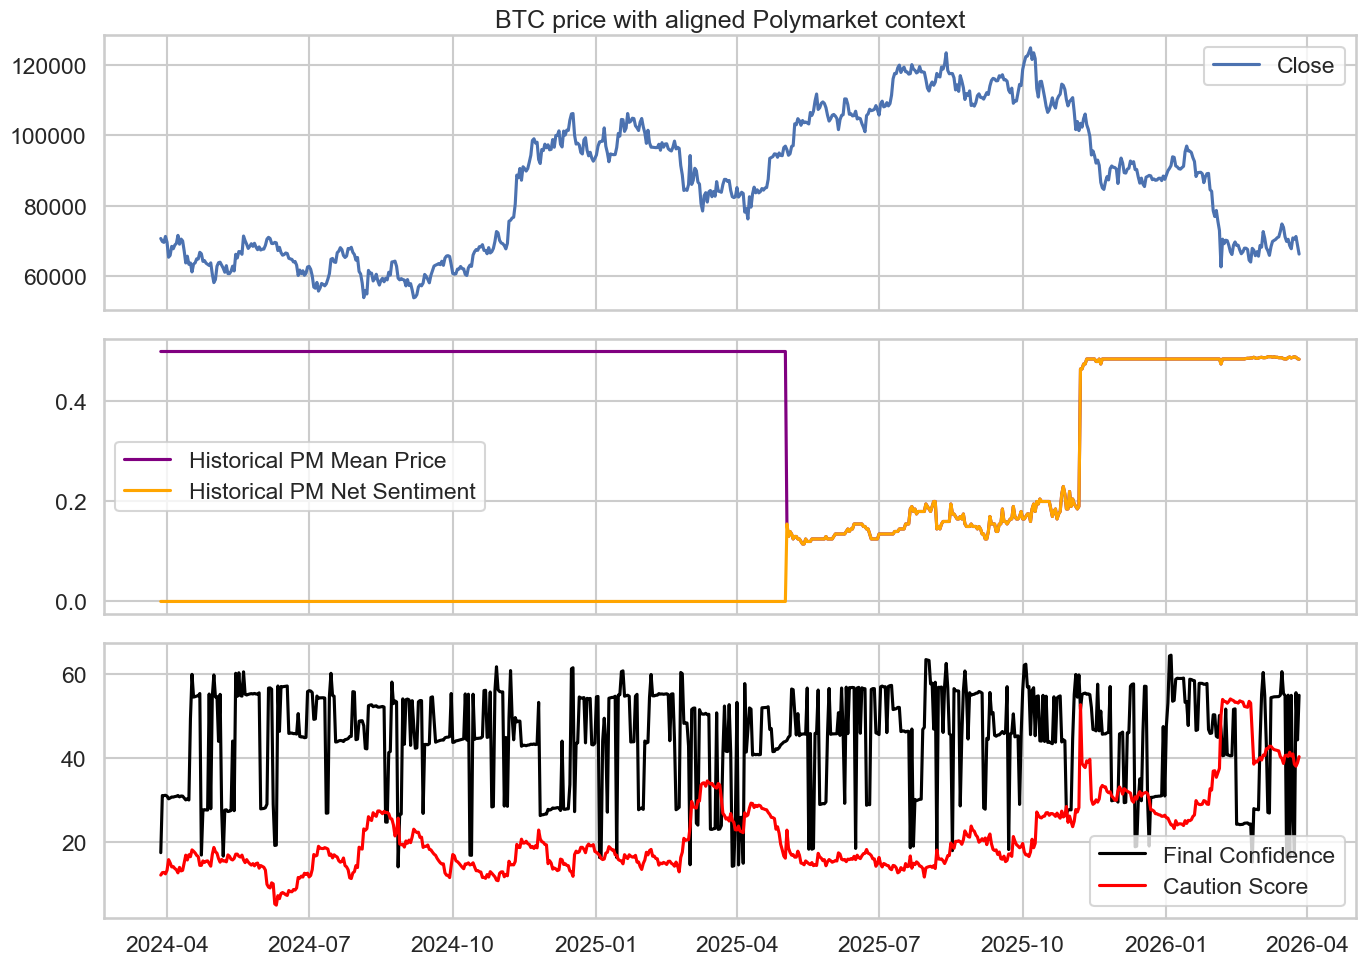

In [7]:
latest = fused_data.iloc[-1]

# CHANGED HERE: decision card now reports both snapshot Polymarket context and historically aligned Polymarket daily features.
decision_card = pd.Series({
    'Asset': asset_label,
    'Base Direction': latest['BaseDirection'],
    'Technical Score': latest['TechnicalScore'],
    'Technical Confidence': latest['TechnicalConfidence'],
    'PM Snapshot Net Sentiment': pm_snapshot_aggregate['pm_net_sentiment'],
    'PM Historical Net Sentiment': latest['pm_hist_net_sentiment'],
    'PM Historical Avg Spread': latest['pm_hist_avg_spread'],
    'PM Historical Dispersion': latest['pm_hist_dispersion'],
    'Caution Score': latest['CautionScore'],
    'Risk Zone': latest['RiskZone'],
    'Final Confidence': latest['FinalConfidence'],
    'Recommended Position Size': latest['PositionSize'],
    'Final Action': latest['FinalAction'],
}).to_frame('Value')
display(decision_card)

if not tagged_polymarket.empty:
    explanation = tagged_polymarket[['question', 'direction', 'theme', 'mid', 'spread', 'days_to_resolution']].head(10)
    display(explanation)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(fused_data.index, fused_data['Close'], label='Close')
axes[0].set_title(f'{asset_label} price with aligned Polymarket context')
axes[0].legend()
axes[1].plot(fused_data.index, fused_data['pm_hist_mean_price'], label='Historical PM Mean Price', color='purple')
axes[1].plot(fused_data.index, fused_data['pm_hist_net_sentiment'], label='Historical PM Net Sentiment', color='orange')
axes[1].legend()
axes[2].plot(fused_data.index, fused_data['FinalConfidence'], label='Final Confidence', color='black')
axes[2].plot(fused_data.index, fused_data['CautionScore'], label='Caution Score', color='red')
axes[2].legend()
plt.tight_layout()
plt.show()


## 9. Scenario Analysis

This section asks how the trade changes if Polymarket sentiment or market structure shifts. It is useful for understanding whether the setup is robust or fragile.


,Scenario,FinalConfidence,AdjustedCaution,FinalAction,PositionSize
0,Base,54.971803,40.337788,Short,0.25
1,PM sentiment improves,56.221803,40.337788,Short,0.50
2,PM sentiment weakens,53.721803,40.337788,Short,0.25
3,Spreads widen,51.971803,52.337788,Short,0.25
4,Event risk rises,52.971803,48.337788,Short,0.25
5,Better PM and lower event risk,57.971803,34.337788,Short,0.50


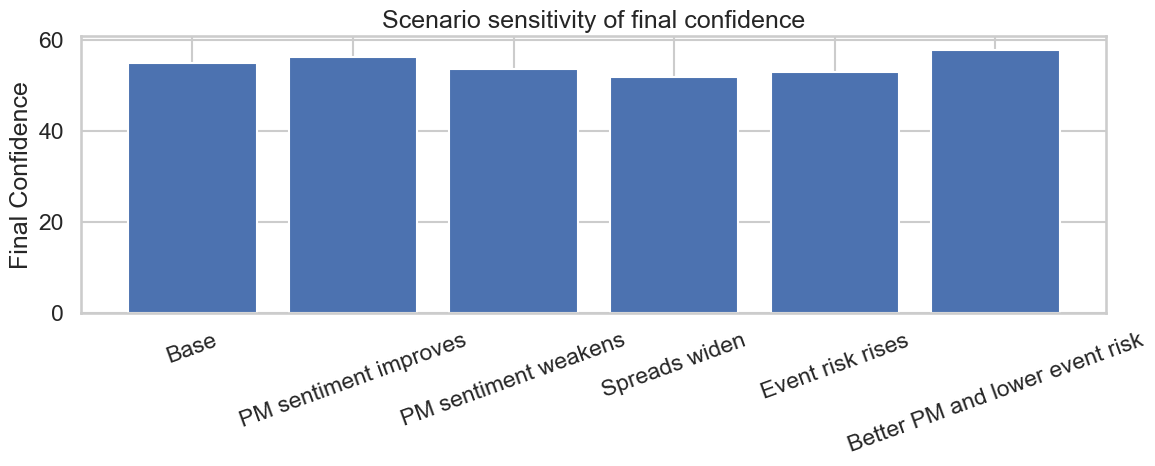

In [8]:
def scenario_adjusted_confidence(latest_row, sentiment_shift=0.0, spread_multiplier=1.0, event_risk_shift=0.0):
    # CHANGED HERE: scenarios now perturb the historically aligned Polymarket features instead of snapshot-only aggregates.
    pm_sent = float(latest_row['pm_hist_liq_weighted_sentiment']) + sentiment_shift
    pm_sent = float(np.clip(pm_sent, -1, 1))
    pm_quality = float(min(pm_snapshot_aggregate.get('pm_market_quality', 0.0), 1.0))
    conflict = float(latest_row['pm_hist_dispersion']) if pd.notna(latest_row['pm_hist_dispersion']) else 0.0

    adjusted_caution = np.clip(
        latest_row['CautionScore'] + 20 * (spread_multiplier - 1) + 20 * event_risk_shift,
        0,
        100,
    )
    confidence = np.clip(
        0.55 * latest_row['TechnicalConfidence']
        + 25 * np.clip(0.5 + 0.5 * pm_sent, 0, 1)
        + 10 * pm_quality
        - 10 * conflict
        - 0.25 * adjusted_caution,
        0,
        100,
    )
    if confidence < confidence_trade_threshold or adjusted_caution >= avoid_threshold:
        action = 'No Trade'
        size = 0.0
    else:
        action = latest_row['BaseDirection'] if latest_row['BaseDirection'] in {'Long', 'Short'} else 'No Trade'
        size = 0.25 if confidence < 55 else 0.50 if confidence < 70 else 0.75 if confidence < 85 else 1.0
    return {'FinalConfidence': confidence, 'AdjustedCaution': adjusted_caution, 'FinalAction': action, 'PositionSize': size}


scenarios = pd.DataFrame([
    {'Scenario': 'Base', **scenario_adjusted_confidence(latest, 0.0, 1.0, 0.0)},
    {'Scenario': 'PM sentiment improves', **scenario_adjusted_confidence(latest, 0.10, 1.0, 0.0)},
    {'Scenario': 'PM sentiment weakens', **scenario_adjusted_confidence(latest, -0.10, 1.0, 0.0)},
    {'Scenario': 'Spreads widen', **scenario_adjusted_confidence(latest, 0.0, 1.6, 0.0)},
    {'Scenario': 'Event risk rises', **scenario_adjusted_confidence(latest, 0.0, 1.0, 0.4)},
    {'Scenario': 'Better PM and lower event risk', **scenario_adjusted_confidence(latest, 0.12, 0.9, -0.2)},
])
display(scenarios)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(scenarios['Scenario'], scenarios['FinalConfidence'])
ax.set_title('Scenario sensitivity of final confidence')
ax.set_ylabel('Final Confidence')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 10. Backtest Comparison

This section compares three variants:

1. Technical-only
2. Technical plus Polymarket confirmation filter
3. Technical plus Polymarket confidence-based sizing

The purpose is to test whether Polymarket actually improves the trading process.


,Variant,Total Return,Max Drawdown,Hit Rate,Average Exposure,Trades / Turnover Proxy
0,Technical Only,-0.269049,-0.441723,0.376712,0.782192,141.00
1,Technical + PM Filter,-0.149695,-0.248205,0.083562,0.171233,38.00
2,Technical + PM Sizing,-0.038559,-0.123487,0.365753,0.247603,69.25


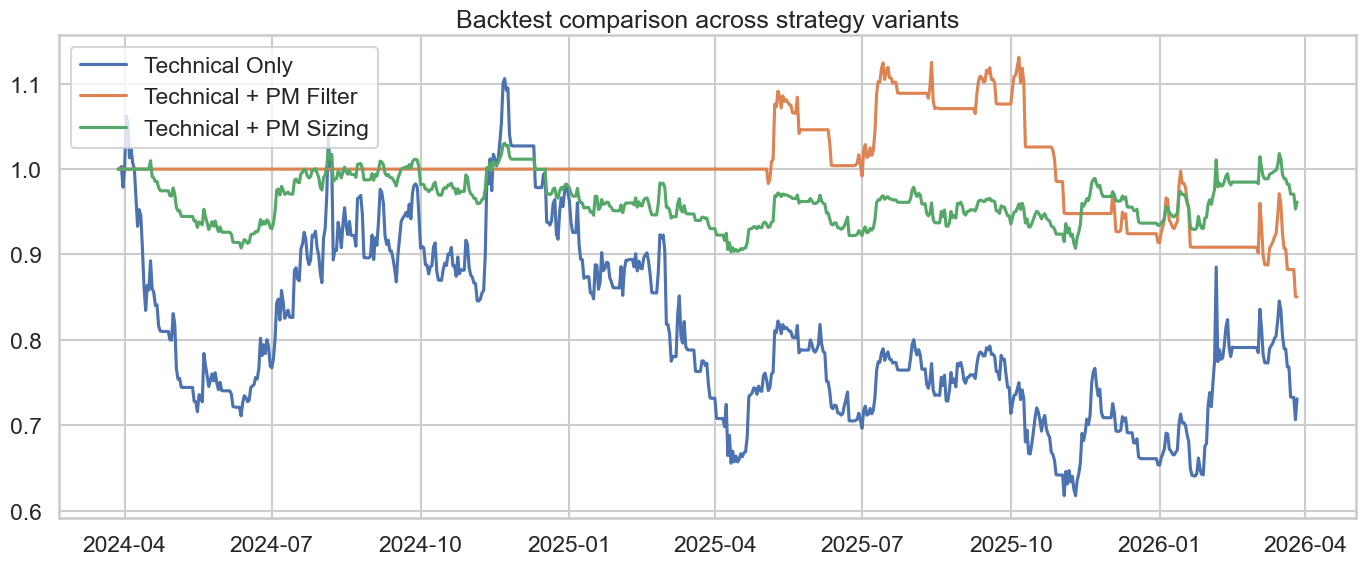

In [9]:
def direction_to_position(direction):
    return {'Long': 1, 'Short': -1, 'Flat': 0, 'No Trade': 0}.get(direction, 0)


def run_backtest_variants(fused_df, fee_bps=5):
    bt = fused_df.copy()
    bt['BasePosition'] = bt['BaseDirection'].map(direction_to_position).fillna(0)
    bt['Return_1D'] = bt['Return_1D'].fillna(0)

    bt['TechOnlyPosition'] = bt['BasePosition'].shift(1).fillna(0)
    bt['TechOnlyTurnover'] = bt['TechOnlyPosition'].diff().abs().fillna(bt['TechOnlyPosition'].abs())
    bt['TechOnlyReturn'] = bt['TechOnlyPosition'] * bt['Return_1D'] - bt['TechOnlyTurnover'] * (fee_bps / 10000)
    bt['TechOnlyEquity'] = (1 + bt['TechOnlyReturn']).cumprod()

    bt['PMFilteredSignal'] = np.where((bt['PMAgreement'] == 1) & (bt['FinalConfidence'] >= confidence_trade_threshold), bt['BasePosition'], 0)
    bt['PMFilteredPosition'] = bt['PMFilteredSignal'].shift(1).fillna(0)
    bt['PMFilteredTurnover'] = bt['PMFilteredPosition'].diff().abs().fillna(bt['PMFilteredPosition'].abs())
    bt['PMFilteredReturn'] = bt['PMFilteredPosition'] * bt['Return_1D'] - bt['PMFilteredTurnover'] * (fee_bps / 10000)
    bt['PMFilteredEquity'] = (1 + bt['PMFilteredReturn']).cumprod()

    bt['PMSizedSignal'] = bt['BasePosition'] * bt['PositionSize']
    bt['PMSizedPosition'] = bt['PMSizedSignal'].shift(1).fillna(0)
    bt['PMSizedTurnover'] = bt['PMSizedPosition'].diff().abs().fillna(bt['PMSizedPosition'].abs())
    bt['PMSizedReturn'] = bt['PMSizedPosition'] * bt['Return_1D'] - bt['PMSizedTurnover'] * (fee_bps / 10000)
    bt['PMSizedEquity'] = (1 + bt['PMSizedReturn']).cumprod()
    return bt


def summarize_backtests(bt):
    rows = []
    for label, ret_col, eq_col, pos_col in [
        ('Technical Only', 'TechOnlyReturn', 'TechOnlyEquity', 'TechOnlyPosition'),
        ('Technical + PM Filter', 'PMFilteredReturn', 'PMFilteredEquity', 'PMFilteredPosition'),
        ('Technical + PM Sizing', 'PMSizedReturn', 'PMSizedEquity', 'PMSizedPosition'),
    ]:
        equity = bt[eq_col]
        returns = bt[ret_col]
        drawdown = equity / equity.cummax() - 1
        rows.append({
            'Variant': label,
            'Total Return': equity.iloc[-1] - 1,
            'Max Drawdown': drawdown.min(),
            'Hit Rate': (returns > 0).mean(),
            'Average Exposure': bt[pos_col].abs().mean(),
            'Trades / Turnover Proxy': bt[pos_col].diff().abs().sum(),
        })
    return pd.DataFrame(rows)


backtest_variants = run_backtest_variants(fused_data)
backtest_summary = summarize_backtests(backtest_variants)
display(backtest_summary)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(backtest_variants.index, backtest_variants['TechOnlyEquity'], label='Technical Only')
ax.plot(backtest_variants.index, backtest_variants['PMFilteredEquity'], label='Technical + PM Filter')
ax.plot(backtest_variants.index, backtest_variants['PMSizedEquity'], label='Technical + PM Sizing')
ax.set_title('Backtest comparison across strategy variants')
ax.legend()
plt.tight_layout()
plt.show()


Simulation summary


,Strategy,Final Equity,Total Return %,Max Drawdown %,Round Trips,Win Rate %,Stops,Targets,Signal Exits,PM Exits,Skipped PM Entries
0,Without PM,9706.832829,-2.931672,-3.851702,121,48.760331,105,16,0,0,0
1,With PM,9971.658341,-0.283417,-1.660758,21,33.333333,15,6,0,0,135


Round-trip P&L (Without PM)


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
101,2025-08-07,2025-08-10,0.006549,770.653369,780.223329,9.569960,STOP,9936.907588,-0.630924
102,2025-08-11,2025-08-12,0.006438,765.485068,772.457598,6.972530,STOP,9943.880119,-0.561199
103,2025-08-13,2025-08-16,0.006490,800.229307,761.389307,-38.840000,STOP,9905.040119,-0.949599
104,2025-08-17,2025-08-19,0.006548,770.142722,737.691096,-32.451627,STOP,9872.588492,-1.274115
105,2025-08-20,2025-08-21,0.006645,760.530276,745.938825,-14.591451,STOP,9857.997041,-1.420030
106,2025-08-22,2025-08-24,0.006565,768.313906,743.737703,-24.576203,STOP,9833.420838,-1.665792
107,2025-09-11,2025-09-12,0.006548,757.513014,759.127993,1.614979,STOP,9835.035817,-1.649642
108,2025-09-13,2025-09-15,0.006552,760.824212,755.252202,-5.572010,STOP,9829.463808,-1.705362
109,2025-09-16,2025-09-18,0.006489,759.362152,758.999484,-0.362668,STOP,9829.101140,-1.708989
110,2025-09-19,2025-09-21,0.006535,757.180248,752.414425,-4.765823,STOP,9824.335316,-1.756647


Round-trip P&L (With PM)


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
1,2024-07-15,2024-07-17,0.007366,478.870006,471.577416,-7.292590,STOP,9945.451326,-0.545487
2,2024-07-19,2024-07-31,0.011314,758.765364,730.033155,-28.732209,STOP,9916.719116,-0.832809
3,2024-08-23,2024-08-27,0.009434,604.889812,560.531781,-44.358031,STOP,9872.361086,-1.276389
4,2024-09-18,2024-10-01,0.011667,735.728127,708.747014,-26.981112,STOP,9845.379973,-1.546200
5,2024-10-14,2024-10-28,0.011226,750.863356,783.583447,32.720091,TARGET,9878.100064,-1.218999
6,2024-10-29,2024-11-06,0.010526,757.982313,795.008117,37.025804,STOP,9915.125868,-0.848741
7,2024-11-07,2024-11-19,0.008486,658.635589,782.480659,123.845069,TARGET,10038.970937,0.389709
8,2024-11-20,2025-01-09,0.007530,735.078866,695.386583,-39.692283,STOP,9999.278654,-0.007213
9,2025-01-15,2025-02-02,0.007459,754.973648,727.596831,-27.376817,STOP,9971.901837,-0.280982
10,2025-04-21,2025-05-06,0.007979,737.101105,771.189986,34.088882,TARGET,10005.990718,0.059907


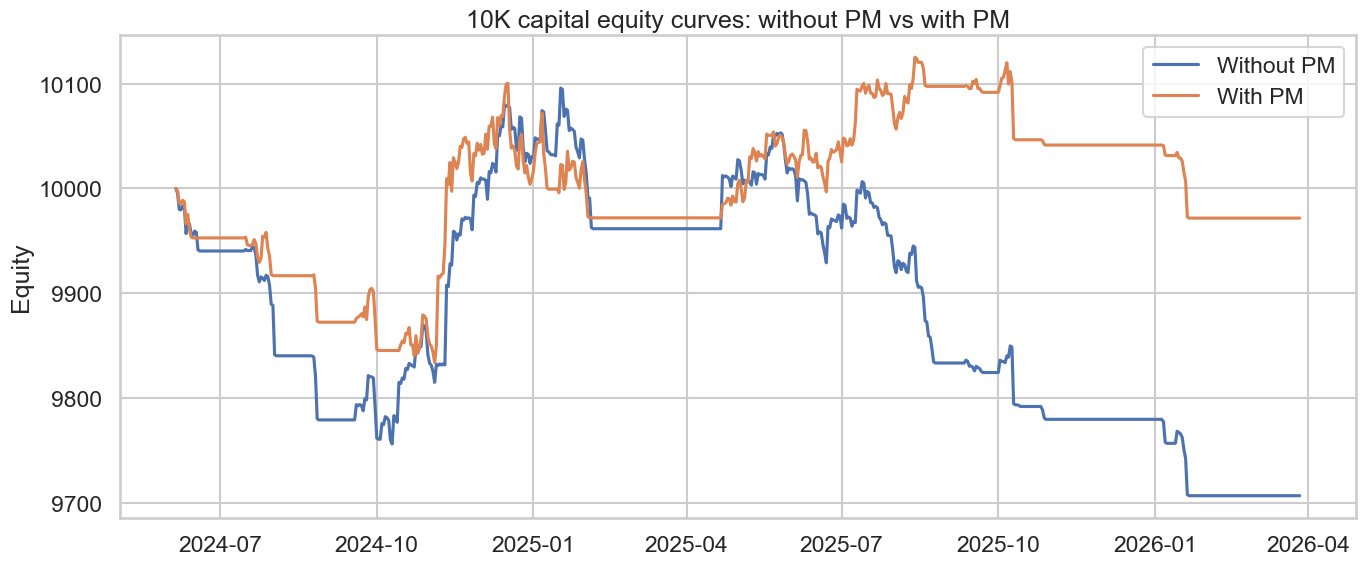

In [10]:
# CHANGED HERE: single-cell trade simulator that emulates the old 10K risk-managed strategy in two versions:
# 1) Without PM: pure rolling-mean long-only trading.
# 2) With PM: same trade engine, but Polymarket filters entries, scales size, and can trigger early exits.

# ------------------------------------------------------------
# Strategy configuration pulled from the older trading notebook
# ------------------------------------------------------------
sim_initial_cash = 10_000.0
sim_risk_per_trade = 0.011630049699125568
sim_max_position = 0.07691911910746403
sim_stop_loss_pct = 0.00318888532686275
sim_target_pct = 0.009930545954923087
sim_slippage_pct = 0.0005   # 5 bps slippage per side
sim_fee_pct = 0.001         # 10 bps fee per side
sim_rolling_window = min(70, max(5, len(feature_data) - 1))
sim_pm_min_confidence = float(confidence_trade_threshold)
sim_pm_exit_confidence = max(20.0, sim_pm_min_confidence - 10.0)
sim_pm_negative_sentiment_threshold = 0.0

# ------------------------------------------------------------
# Build one shared input table for both simulations
# ------------------------------------------------------------
trade_input = feature_data.copy().sort_index()
for col in [
    'FinalAction', 'PositionSize', 'FinalConfidence', 'RiskZone',
    'pm_hist_liq_weighted_sentiment', 'pm_hist_net_sentiment'
]:
    trade_input[col] = fused_data[col] if col in fused_data.columns else np.nan

trade_input['rolling_mean'] = trade_input['Close'].rolling(sim_rolling_window).mean()
trade_input['signal'] = np.where(
    trade_input['Close'] > trade_input['rolling_mean'], 1,
    np.where(trade_input['Close'] < trade_input['rolling_mean'], -1, 0)
)
trade_input['decision'] = np.where(
    trade_input['rolling_mean'].isna(), 'NA',
    np.where(trade_input['signal'] == 1, 'BUY', np.where(trade_input['signal'] == -1, 'SELL', 'HOLD'))
)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def safe_float(value, default=0.0):
    return default if pd.isna(value) else float(value)


def position_size_units(cash, entry_price, stop_loss_pct, risk_per_trade):
    # Same logic as the older notebook: risk a fixed fraction of cash based on stop-loss distance.
    risk_amount = cash * risk_per_trade
    stop_distance = entry_price * stop_loss_pct
    if stop_distance <= 0:
        return 0.0
    return risk_amount / stop_distance


def build_roundtrip_table(trades_df, initial_cash):
    # Compress multiple BUY fills into one round trip that ends on the next full SELL.
    roundtrips = []
    open_cost = 0.0
    open_qty = 0.0
    entry_time = None

    for _, trade in trades_df.iterrows():
        if trade['side'] == 'BUY':
            if open_qty == 0:
                entry_time = trade['timestamp']
            open_cost += (trade['notional'] + trade['fee'])
            open_qty += trade['qty']
        else:
            proceeds = trade['notional'] - trade['fee']
            pnl = proceeds - open_cost
            roundtrips.append({
                'entry_time': entry_time,
                'exit_time': trade['timestamp'],
                'qty': open_qty,
                'buy_cost_incl_fees': open_cost,
                'sell_proceeds_after_fee': proceeds,
                'realized_pnl': pnl,
                'exit_reason': trade.get('reason', 'SELL'),
            })
            open_cost = 0.0
            open_qty = 0.0
            entry_time = None

    expected_cols = [
        'entry_time', 'exit_time', 'qty', 'buy_cost_incl_fees',
        'sell_proceeds_after_fee', 'realized_pnl', 'exit_reason',
        'cum_equity', 'cum_return_pct'
    ]
    roundtrip_df = pd.DataFrame(roundtrips)
    if roundtrip_df.empty:
        return pd.DataFrame(columns=expected_cols)

    roundtrip_df['cum_equity'] = initial_cash + roundtrip_df['realized_pnl'].cumsum()
    roundtrip_df['cum_return_pct'] = ((roundtrip_df['cum_equity'] - initial_cash) / initial_cash) * 100
    return roundtrip_df[expected_cols]


def run_trade_simulation(data, use_pm=False, label='Without PM'):
    # Walk the bars sequentially and create the exact fill ledger / round-trip table style from the older notebook.
    cash = float(sim_initial_cash)
    position = 0.0
    avg_entry = None
    trades = []
    equity_curve = []
    skipped_pm_entries = 0

    for ts, row in data.iterrows():
        if pd.isna(row['rolling_mean']):
            continue

        price = float(row['Close'])
        bar_high = float(row['High']) if 'High' in row.index and pd.notna(row['High']) else price
        bar_low = float(row['Low']) if 'Low' in row.index and pd.notna(row['Low']) else price
        sig = int(row['signal'])
        equity_now = cash + position * price
        equity_curve.append((ts, equity_now))

        # Base size from the old notebook's risk-per-trade formula.
        size = float(position_size_units(cash, price, sim_stop_loss_pct, sim_risk_per_trade))

        # Cap total exposure as a fixed fraction of current equity.
        max_position_value = sim_max_position * equity_now
        desired_position_value = (position + size) * price
        if abs(desired_position_value) > max_position_value:
            target_position_value = np.sign(desired_position_value) * max_position_value
            target_position_units = target_position_value / price if price > 0 else 0.0
            size = target_position_units - position

        # PM overlay only affects the PM strategy.
        pm_multiplier = 1.0
        pm_entry_ok = True
        pm_exit = False
        if use_pm:
            pm_multiplier = np.clip(safe_float(row.get('PositionSize', 0.0), 0.0), 0.0, 1.0)
            pm_action = row.get('FinalAction', 'No Trade')
            pm_confidence = safe_float(row.get('FinalConfidence', 0.0), 0.0)
            pm_risk_zone = str(row.get('RiskZone', 'Tradeable'))
            pm_sentiment = safe_float(row.get('pm_hist_liq_weighted_sentiment', 0.0), 0.0)

            pm_entry_ok = (
                pm_action == 'Long'
                and pm_confidence >= sim_pm_min_confidence
                and pm_multiplier > 0
                and pm_risk_zone != 'Avoid'
            )
            size *= pm_multiplier

            if position > 0 and (
                pm_confidence < sim_pm_exit_confidence
                or pm_risk_zone == 'Avoid'
                or pm_sentiment < sim_pm_negative_sentiment_threshold
            ):
                pm_exit = True

        # Check hard exits on the active position.
        stop_hit = False
        target_hit = False
        if position > 0 and avg_entry is not None:
            stop_price = avg_entry * (1 - sim_stop_loss_pct)
            target_price = avg_entry * (1 + sim_target_pct)
            if bar_low <= stop_price:
                stop_hit = True
            elif bar_high >= target_price:
                target_hit = True

        # BUY: long-only entry / add-on, same style as the older notebook.
        if sig == 1 and size > 0 and (pm_entry_ok if use_pm else True):
            fill = price * (1 + sim_slippage_pct)
            max_affordable_qty = cash / (fill * (1 + sim_fee_pct)) if fill > 0 else 0.0
            size = min(size, max_affordable_qty)
            if size > 0:
                notional = fill * size
                fee = sim_fee_pct * notional
                cash -= (notional + fee)
                old_pos = position
                position += size
                avg_entry = fill if old_pos == 0 else ((avg_entry * old_pos + fill * size) / (old_pos + size))
                trades.append({
                    'timestamp': ts,
                    'strategy': label,
                    'side': 'BUY',
                    'reason': 'SIGNAL',
                    'fill_price': fill,
                    'qty': size,
                    'notional': notional,
                    'fee': fee,
                    'cash_after': cash,
                    'position_after': position,
                    'pm_multiplier': pm_multiplier,
                })
        elif sig == 1 and use_pm and not pm_entry_ok:
            skipped_pm_entries += 1

        # SELL: close the full long when the signal flips, stop/target is hit, or PM deteriorates.
        elif position > 0 and (sig == -1 or stop_hit or target_hit or (use_pm and pm_exit)):
            fill = price * (1 - sim_slippage_pct)
            qty = position
            notional = fill * qty
            fee = sim_fee_pct * notional
            cash += (notional - fee)

            exit_reason = 'STOP' if stop_hit else ('TARGET' if target_hit else ('PM_EXIT' if use_pm and pm_exit else 'SIGNAL'))
            position = 0.0
            avg_entry = None
            trades.append({
                'timestamp': ts,
                'strategy': label,
                'side': 'SELL',
                'reason': exit_reason,
                'fill_price': fill,
                'qty': qty,
                'notional': notional,
                'fee': fee,
                'cash_after': cash,
                'position_after': position,
                'pm_multiplier': pm_multiplier,
            })

    # Add the final marked-to-market equity point.
    if not data.empty:
        final_ts = data.index[-1]
        final_price = float(data['Close'].iloc[-1])
        equity_curve.append((final_ts, cash + position * final_price))

    trades_df = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True) if trades else pd.DataFrame(columns=[
        'timestamp', 'strategy', 'side', 'reason', 'fill_price', 'qty', 'notional', 'fee', 'cash_after', 'position_after', 'pm_multiplier'
    ])
    roundtrip_df = build_roundtrip_table(trades_df, sim_initial_cash)
    equity_df = pd.DataFrame(equity_curve, columns=['timestamp', 'equity']).drop_duplicates(subset=['timestamp'], keep='last') if equity_curve else pd.DataFrame(columns=['timestamp', 'equity'])

    final_equity = float(equity_df['equity'].iloc[-1]) if not equity_df.empty else sim_initial_cash
    max_drawdown = float((equity_df['equity'] / equity_df['equity'].cummax() - 1).min()) if not equity_df.empty else 0.0
    win_rate = float((roundtrip_df['realized_pnl'] > 0).mean()) if not roundtrip_df.empty else np.nan
    summary = {
        'Strategy': label,
        'Final Equity': final_equity,
        'Total Return %': ((final_equity - sim_initial_cash) / sim_initial_cash) * 100,
        'Max Drawdown %': max_drawdown * 100,
        'Round Trips': int(len(roundtrip_df)),
        'Win Rate %': win_rate * 100 if pd.notna(win_rate) else np.nan,
        'Stops': int((roundtrip_df['exit_reason'] == 'STOP').sum()) if not roundtrip_df.empty else 0,
        'Targets': int((roundtrip_df['exit_reason'] == 'TARGET').sum()) if not roundtrip_df.empty else 0,
        'Signal Exits': int((roundtrip_df['exit_reason'] == 'SIGNAL').sum()) if not roundtrip_df.empty else 0,
        'PM Exits': int((roundtrip_df['exit_reason'] == 'PM_EXIT').sum()) if (use_pm and not roundtrip_df.empty) else 0,
        'Skipped PM Entries': skipped_pm_entries,
    }
    return {
        'trades_df': trades_df,
        'roundtrip_df': roundtrip_df,
        'equity_df': equity_df,
        'summary': summary,
    }


# ------------------------------------------------------------
# Run both simulations from the same market data
# ------------------------------------------------------------
without_pm_result = run_trade_simulation(trade_input, use_pm=False, label='Without PM')
with_pm_result = run_trade_simulation(trade_input, use_pm=True, label='With PM')

simulation_summary = pd.DataFrame([
    without_pm_result['summary'],
    with_pm_result['summary'],
])

print('Simulation summary')
display(simulation_summary)

print('Round-trip P&L (Without PM)')
display(without_pm_result['roundtrip_df'].tail(20))

print('Round-trip P&L (With PM)')
display(with_pm_result['roundtrip_df'].tail(20))

fig, ax = plt.subplots(figsize=(14, 6))
if not without_pm_result['equity_df'].empty:
    ax.plot(without_pm_result['equity_df']['timestamp'], without_pm_result['equity_df']['equity'], label='Without PM')
if not with_pm_result['equity_df'].empty:
    ax.plot(with_pm_result['equity_df']['timestamp'], with_pm_result['equity_df']['equity'], label='With PM')
ax.set_title('10K capital equity curves: without PM vs with PM')
ax.set_ylabel('Equity')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Iteration 2: Five-Tab Strategy Extensions

This iteration extends the asset-first trading notebook into a closer Yhack-style product surface.

It adds:
- Tab 1 style payoff visualizations across probability outcomes and holding windows
- Tab 2 style hedge comparisons for spot, perp-style, option-style, and PM overlays
- Tab 3 style scenario windows for earlier vs later event resolution
- Tab 4 style portfolio views across BTC, ETH, and SOL
- Tab 5 style educational diagnostics showing why PM changes trade sizing and exits


In [11]:
# CHANGED HERE: iteration-2 research inputs for the five-tab extensions.
iter2_assets = {
    'BTC': 'BTC-USD',
    'ETH': 'ETH-USD',
    'SOL': 'SOL-USD',
}
iter2_portfolio_weights = {
    'BTC': 0.50,
    'ETH': 0.30,
    'SOL': 0.20,
}
iter2_resolution_windows = [3, 7, 14, 30]
iter2_probability_grid = np.round(np.linspace(0.10, 0.90, 17), 2)
iter2_return_grid = np.linspace(-0.20, 0.20, 81)
iter2_selected_asset = asset_label if asset_label in iter2_assets else 'BTC'
iter2_top_markets = 12
iter2_pm_probability_floor = 0.45
iter2_pm_probability_ceiling = 0.55
iter2_perp_hedge_ratio = 0.50
iter2_option_floor = -0.08
iter2_option_premium_pct = 0.01
iter2_pm_hedge_contract_cost = 0.08
iter2_pm_event_threshold = -0.05
print({'selected_asset': iter2_selected_asset, 'assets': iter2_assets, 'portfolio_weights': iter2_portfolio_weights})


{'selected_asset': 'BTC', 'assets': {'BTC': 'BTC-USD', 'ETH': 'ETH-USD', 'SOL': 'SOL-USD'}, 'portfolio_weights': {'BTC': 0.5, 'ETH': 0.3, 'SOL': 0.2}}


In [12]:
# CHANGED HERE: build a reusable multi-asset research bundle so the notebook can support portfolio and strategy tabs.
def prepare_trade_input(feature_df, fused_df, rolling_window):
    trade_input = feature_df.copy().sort_index()
    for col in [
        'FinalAction', 'PositionSize', 'FinalConfidence', 'RiskZone',
        'pm_hist_liq_weighted_sentiment', 'pm_hist_net_sentiment', 'pm_hist_mean_price'
    ]:
        trade_input[col] = fused_df[col] if col in fused_df.columns else np.nan
    trade_input['rolling_mean'] = trade_input['Close'].rolling(rolling_window).mean()
    trade_input['signal'] = np.where(
        trade_input['Close'] > trade_input['rolling_mean'], 1,
        np.where(trade_input['Close'] < trade_input['rolling_mean'], -1, 0)
    )
    return trade_input


def build_asset_bundle(asset_label_local, ticker_local):
    # Fetch underlying market data for this asset.
    market_data_local, market_source_local = get_market_data(ticker_local, start_date, end_date, interval, market_data_mode)
    feature_local = build_feature_lab(market_data_local)

    # Fetch and tag related Polymarket markets for this asset.
    polymarket_board_local = pd.DataFrame()
    try:
        if polymarket_use_live:
            polymarket_board_local = build_polymarket_market_board(asset_label_local, polymarket_config, polymarket_market_limit)
    except Exception:
        polymarket_board_local = pd.DataFrame()
    tagged_local = tag_polymarket_questions(polymarket_board_local, asset_label_local)

    # Build snapshot and historical PM features, then fuse them into the technical frame.
    pm_snapshot_local = aggregate_polymarket_snapshot(tagged_local)
    pm_history_local = build_historical_polymarket_panel(
        tagged_local,
        polymarket_config,
        start_date,
        end_date,
        feature_local.index,
        alignment_freq=polymarket_alignment_freq,
        fidelity_minutes=polymarket_history_fidelity_minutes,
        max_markets=iter2_top_markets,
    )
    fused_local = fuse_signals(feature_local, pm_snapshot_local, pm_history_local, avoid_threshold)

    # Prepare the same trade input shape used by the legacy-style simulator.
    rolling_window_local = min(sim_rolling_window, max(5, len(feature_local) - 1))
    trade_input_local = prepare_trade_input(feature_local, fused_local, rolling_window_local)

    # Run the without-PM and with-PM trade engines.
    without_pm_local = run_trade_simulation(trade_input_local, use_pm=False, label=f'{asset_label_local} Without PM')
    with_pm_local = run_trade_simulation(trade_input_local, use_pm=True, label=f'{asset_label_local} With PM')

    # Estimate how PM probability changes have historically related to the asset's returns.
    pm_delta = fused_local['pm_hist_mean_price'].diff().replace([np.inf, -np.inf], np.nan)
    asset_ret = feature_local['Return_1D'].replace([np.inf, -np.inf], np.nan)
    if pm_delta.notna().sum() > 5 and pm_delta.var(skipna=True) and pm_delta.var(skipna=True) > 0:
        pm_return_beta = asset_ret.cov(pm_delta) / pm_delta.var(skipna=True)
    else:
        pm_return_beta = 0.0

    return {
        'asset_label': asset_label_local,
        'ticker': ticker_local,
        'market_source': market_source_local,
        'market_data': market_data_local,
        'feature_data': feature_local,
        'polymarket_board': polymarket_board_local,
        'tagged_polymarket': tagged_local,
        'pm_snapshot': pm_snapshot_local,
        'pm_history': pm_history_local,
        'fused_data': fused_local,
        'trade_input': trade_input_local,
        'without_pm': without_pm_local,
        'with_pm': with_pm_local,
        'pm_return_beta': float(pm_return_beta),
    }


iter2_asset_results = {label: build_asset_bundle(label, ticker) for label, ticker in iter2_assets.items()}
iter2_asset_summary = pd.DataFrame([
    {
        'Asset': label,
        'Ticker': result['ticker'],
        'Market Source': result['market_source'],
        'Tagged PM Markets': int(len(result['tagged_polymarket'])),
        'Without PM Final Equity': result['without_pm']['summary']['Final Equity'],
        'With PM Final Equity': result['with_pm']['summary']['Final Equity'],
        'With PM Total Return %': result['with_pm']['summary']['Total Return %'],
        'PM Beta vs Returns': result['pm_return_beta'],
    }
    for label, result in iter2_asset_results.items()
])
display(iter2_asset_summary)


/var/folders/v_/pv32b_4x16b55v2rdc_2dqww0000gn/T/ipykernel_66643/1966004287.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel['pm_hist_liq_weighted_sentiment'] = grouped.apply(lambda g: weighted_mean(g['signed_price'], g['liquidity'].fillna(1))).reindex(panel.index)
/var/folders/v_/pv32b_4x16b55v2rdc_2dqww0000gn/T/ipykernel_66643/1966004287.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel['pm_his

,Asset,Ticker,Market Source,Tagged PM Markets,Without PM Final Equity,With PM Final Equity,With PM Total Return %,PM Beta vs Returns
0,BTC,BTC-USD,Yahoo Finance,1,9706.832829,9971.658341,-0.283417,0.053992
1,ETH,ETH-USD,Yahoo Finance,10,9792.269872,10148.778841,1.487788,-0.147212
2,SOL,SOL-USD,Yahoo Finance,120,9419.666852,9620.208528,-3.797915,0.084113


## 12. Tab 1: Probability / Horizon Payoff Explorer

This section translates Polymarket probability outcomes into expected asset returns using the observed relationship between daily asset returns and PM probability changes, then compares the baseline and PM-sized strategies across holding windows.


,Asset,HorizonDays,FuturePMProbability,ProbabilityDelta,ImpliedAssetReturn,WithoutPM_PnL,WithPM_PnL
0,BTC,3,0.10,-0.3845,-0.006565,-6.587974,-1.646993
1,BTC,3,0.15,-0.3345,-0.005711,-5.931330,-1.482832
2,BTC,3,0.20,-0.2845,-0.004857,-5.274686,-1.318671
3,BTC,3,0.25,-0.2345,-0.004004,-4.618042,-1.154510
4,BTC,3,0.30,-0.1845,-0.003150,-3.961398,-0.990350
5,BTC,3,0.35,-0.1345,-0.002296,-3.304754,-0.826189
6,BTC,3,0.40,-0.0845,-0.001443,-2.648110,-0.662028
7,BTC,3,0.45,-0.0345,-0.000589,-1.991467,-0.497867
8,BTC,3,0.50,0.0155,0.000265,-1.334823,-0.333706
9,BTC,3,0.55,0.0655,0.001118,-0.678179,-0.169545


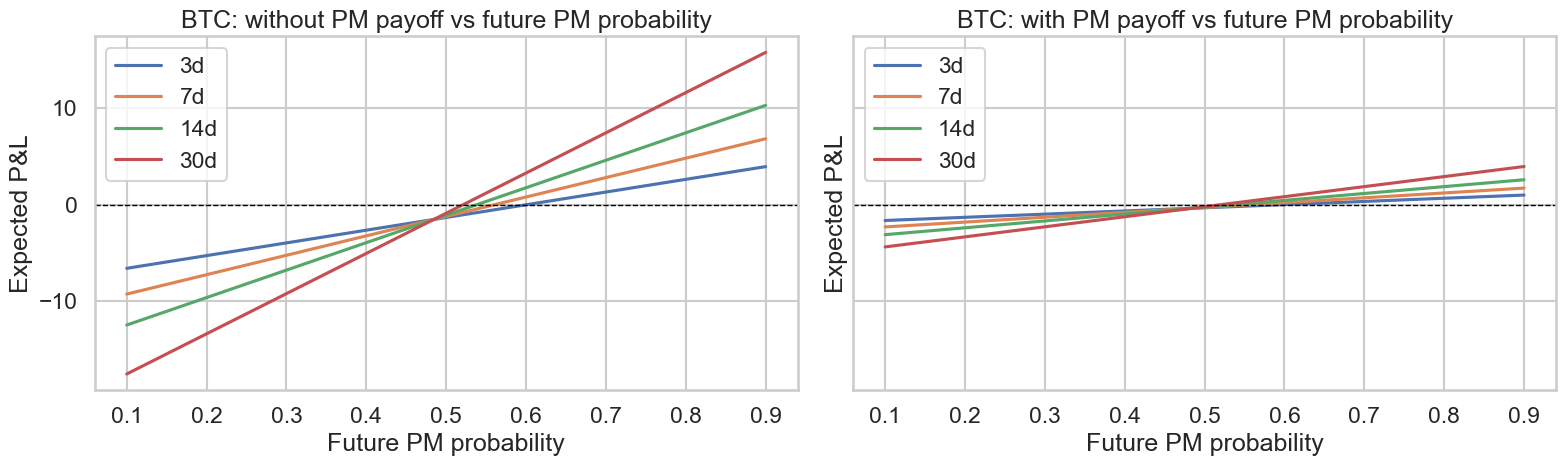

In [13]:
# CHANGED HERE: payoff explorer across probability outcomes and holding windows.
def build_probability_payoff_grid(bundle, horizons, probability_grid):
    fused = bundle['fused_data']
    latest = fused.iloc[-1]
    current_price = float(fused['Close'].iloc[-1])
    current_prob = safe_float(latest.get('pm_hist_mean_price', 0.5), 0.5)
    base_size_units = position_size_units(sim_initial_cash, current_price, sim_stop_loss_pct, sim_risk_per_trade)
    equity_cap_units = (sim_max_position * sim_initial_cash) / current_price if current_price > 0 else 0.0
    base_size_units = min(base_size_units, equity_cap_units)
    pm_size_units = base_size_units * np.clip(safe_float(latest.get('PositionSize', 0.0), 0.0), 0.0, 1.0)
    beta = float(bundle['pm_return_beta'])

    rows = []
    for horizon in horizons:
        sqrt_h = np.sqrt(max(horizon, 1))
        time_scale = sqrt_h / np.sqrt(30)
        holding_cost = sim_fee_pct * current_price * base_size_units * 2
        for future_prob in probability_grid:
            prob_delta = future_prob - current_prob
            expected_return = beta * prob_delta * time_scale
            without_pm_pnl = (base_size_units * current_price * expected_return) - holding_cost
            with_pm_pnl = (pm_size_units * current_price * expected_return) - (sim_fee_pct * current_price * pm_size_units * 2)
            rows.append({
                'Asset': bundle['asset_label'],
                'HorizonDays': horizon,
                'FuturePMProbability': future_prob,
                'ProbabilityDelta': prob_delta,
                'ImpliedAssetReturn': expected_return,
                'WithoutPM_PnL': without_pm_pnl,
                'WithPM_PnL': with_pm_pnl,
            })
    return pd.DataFrame(rows)


iter2_selected_bundle = iter2_asset_results[iter2_selected_asset]
iter2_probability_payoff = build_probability_payoff_grid(iter2_selected_bundle, iter2_resolution_windows, iter2_probability_grid)
display(iter2_probability_payoff.head(12))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for horizon in iter2_resolution_windows:
    subset = iter2_probability_payoff[iter2_probability_payoff['HorizonDays'] == horizon]
    axes[0].plot(subset['FuturePMProbability'], subset['WithoutPM_PnL'], label=f'{horizon}d')
    axes[1].plot(subset['FuturePMProbability'], subset['WithPM_PnL'], label=f'{horizon}d')
axes[0].set_title(f'{iter2_selected_asset}: without PM payoff vs future PM probability')
axes[1].set_title(f'{iter2_selected_asset}: with PM payoff vs future PM probability')
for ax in axes:
    ax.set_xlabel('Future PM probability')
    ax.set_ylabel('Expected P&L')
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.legend()
plt.tight_layout()
plt.show()


## 13. Tab 2 and Tab 3: Hedge Lab and Resolution Scenarios

This section compares simple hedge overlays and then evaluates how earlier vs later resolution windows change expected confidence, size, and P&L.


,ResolutionWindowDays,AdjustedConfidence,ImpliedAssetReturn,WithoutPM_ExpectedPnL,WithPM_ExpectedPnL,SuggestedSizeMultiplier
0,3,59.985803,-0.000265,-0.203560,-0.050890,0.25
1,7,58.919136,-0.000404,-0.310942,-0.077736,0.25
2,14,57.052470,-0.000572,-0.439739,-0.109935,0.25
3,30,52.785803,-0.000837,-0.643712,-0.160928,0.25


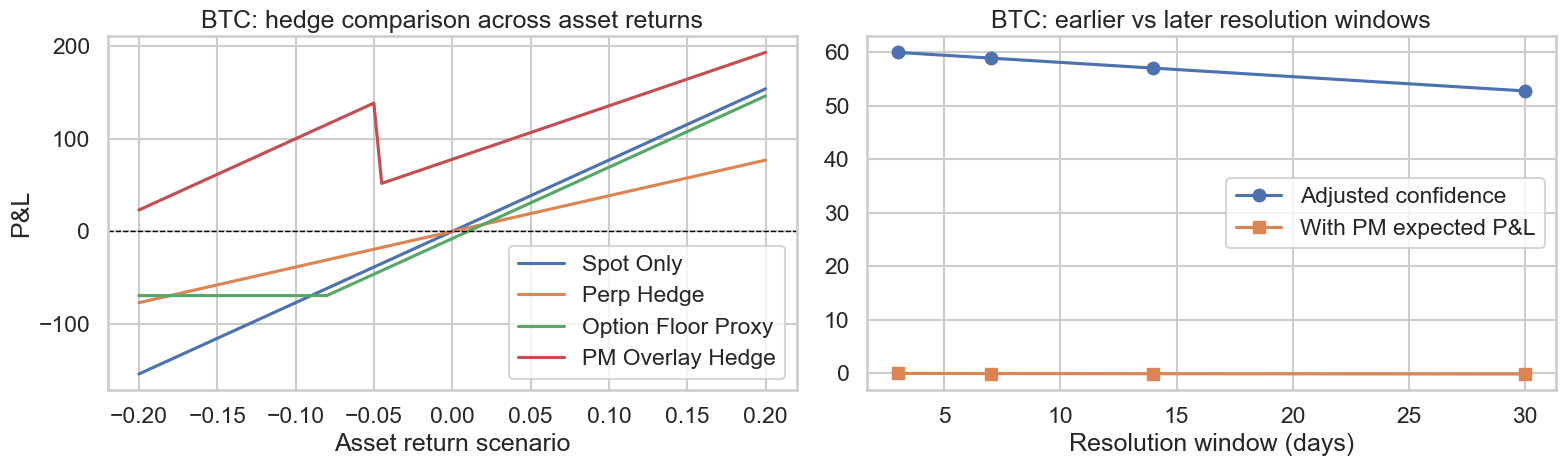

In [14]:
# CHANGED HERE: hedge comparison and explicit sooner-vs-later resolution scenarios.
def build_hedge_profiles(bundle, return_grid, horizon_days=14):
    fused = bundle['fused_data']
    latest = fused.iloc[-1]
    current_price = float(fused['Close'].iloc[-1])
    base_size_units = position_size_units(sim_initial_cash, current_price, sim_stop_loss_pct, sim_risk_per_trade)
    equity_cap_units = (sim_max_position * sim_initial_cash) / current_price if current_price > 0 else 0.0
    base_size_units = min(base_size_units, equity_cap_units)
    pm_size_units = base_size_units * np.clip(safe_float(latest.get('PositionSize', 0.0), 0.0), 0.0, 1.0)
    current_prob = safe_float(latest.get('pm_hist_mean_price', 0.5), 0.5)

    rows = []
    for asset_return in return_grid:
        spot_pnl = base_size_units * current_price * asset_return
        perp_hedge_pnl = spot_pnl - (iter2_perp_hedge_ratio * base_size_units * current_price * asset_return)
        option_floor = max(asset_return, iter2_option_floor)
        option_pnl = (base_size_units * current_price * option_floor) - (iter2_option_premium_pct * base_size_units * current_price)
        bearish_event = 1.0 if asset_return <= iter2_pm_event_threshold else max(0.0, min(1.0, current_prob - asset_return))
        pm_overlay_pnl = spot_pnl + (pm_size_units * current_price * max(0.0, bearish_event - iter2_pm_hedge_contract_cost))
        rows.append({
            'AssetReturn': asset_return,
            'Spot Only': spot_pnl,
            'Perp Hedge': perp_hedge_pnl,
            'Option Floor Proxy': option_pnl,
            'PM Overlay Hedge': pm_overlay_pnl,
        })
    return pd.DataFrame(rows)


def build_resolution_window_table(bundle, windows):
    latest = bundle['fused_data'].iloc[-1]
    current_price = float(bundle['fused_data']['Close'].iloc[-1])
    base_size_units = position_size_units(sim_initial_cash, current_price, sim_stop_loss_pct, sim_risk_per_trade)
    equity_cap_units = (sim_max_position * sim_initial_cash) / current_price if current_price > 0 else 0.0
    base_size_units = min(base_size_units, equity_cap_units)
    pm_size_units = base_size_units * np.clip(safe_float(latest.get('PositionSize', 0.0), 0.0), 0.0, 1.0)
    current_prob = safe_float(latest.get('pm_hist_mean_price', 0.5), 0.5)
    beta = float(bundle['pm_return_beta'])

    rows = []
    for window in windows:
        time_scale = np.sqrt(max(window, 1)) / np.sqrt(30)
        adjusted_confidence = np.clip(
            latest['FinalConfidence'] - (window / max(windows)) * 8 + latest['pm_hist_liq_weighted_sentiment'] * 12,
            0,
            100,
        )
        expected_return = beta * (current_prob - 0.5) * time_scale
        expected_without_pm = base_size_units * current_price * expected_return
        expected_with_pm = pm_size_units * current_price * expected_return
        rows.append({
            'ResolutionWindowDays': window,
            'AdjustedConfidence': adjusted_confidence,
            'ImpliedAssetReturn': expected_return,
            'WithoutPM_ExpectedPnL': expected_without_pm,
            'WithPM_ExpectedPnL': expected_with_pm,
            'SuggestedSizeMultiplier': np.clip(pm_size_units / base_size_units if base_size_units > 0 else 0.0, 0.0, 1.0),
        })
    return pd.DataFrame(rows)


iter2_hedge_profiles = build_hedge_profiles(iter2_selected_bundle, iter2_return_grid, horizon_days=14)
iter2_resolution_table = build_resolution_window_table(iter2_selected_bundle, iter2_resolution_windows)
display(iter2_resolution_table)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for col in ['Spot Only', 'Perp Hedge', 'Option Floor Proxy', 'PM Overlay Hedge']:
    axes[0].plot(iter2_hedge_profiles['AssetReturn'], iter2_hedge_profiles[col], label=col)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'{iter2_selected_asset}: hedge comparison across asset returns')
axes[0].set_xlabel('Asset return scenario')
axes[0].set_ylabel('P&L')
axes[0].legend()

axes[1].plot(iter2_resolution_table['ResolutionWindowDays'], iter2_resolution_table['AdjustedConfidence'], marker='o', label='Adjusted confidence')
axes[1].plot(iter2_resolution_table['ResolutionWindowDays'], iter2_resolution_table['WithPM_ExpectedPnL'], marker='s', label='With PM expected P&L')
axes[1].set_title(f'{iter2_selected_asset}: earlier vs later resolution windows')
axes[1].set_xlabel('Resolution window (days)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 14. Tab 4 and Tab 5: Portfolio View and Educational Diagnostics

This section builds a multi-asset portfolio equity view and then explains the latest PM-enhanced trade using a contribution table and a reason waterfall.


,Variant,Final Equity,Total Return %
0,Without PM Portfolio,9675.030747,-3.249693
1,With PM Portfolio,9954.504528,-0.454955


,Component,Value
0,Technical confidence contribution,38.500000
1,PM confirmation contribution,18.556250
2,PM quality contribution,8.000000
3,PM conflict penalty,-0.000000
4,Caution penalty,-10.084447
5,Final confidence,54.971803
6,Position size,0.250000


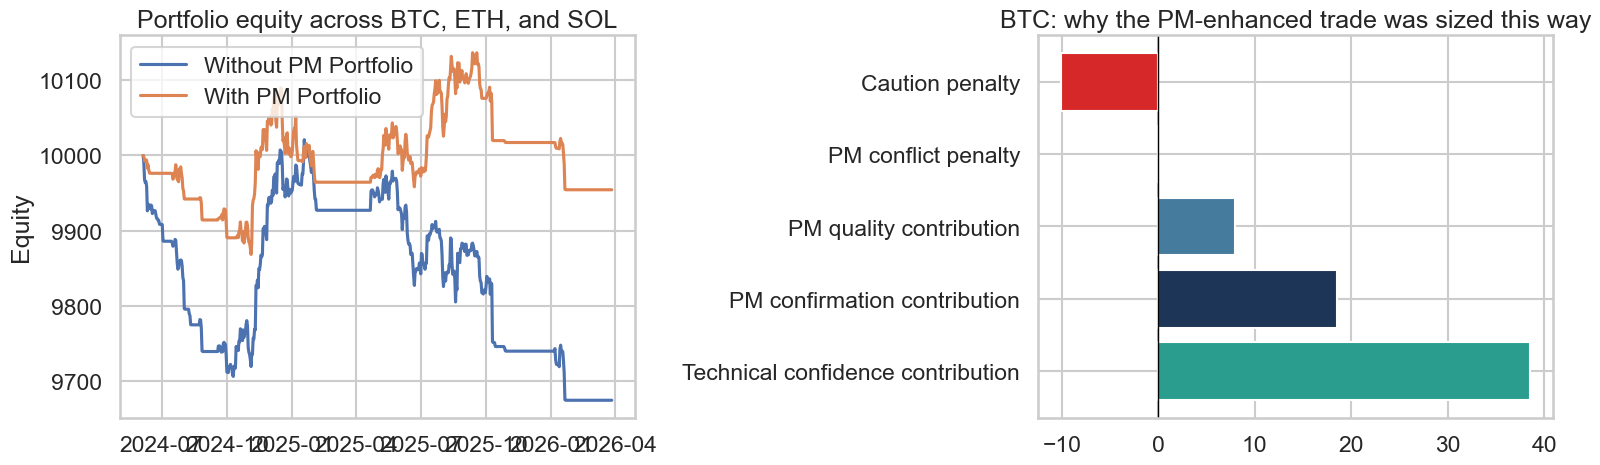

Round-trip P&L (Without PM portfolio assets shown individually)
BTC - Without PM


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
111,2025-10-01,2025-10-02,0.006369,756.813115,767.470637,10.657522,TARGET,9834.992839,-1.650072
112,2025-10-03,2025-10-04,0.006187,757.634112,756.346292,-1.287820,STOP,9833.705019,-1.662950
113,2025-10-05,2025-10-06,0.006124,757.534906,762.842333,5.307427,TARGET,9839.012446,-1.609876
114,2025-10-07,2025-10-08,0.006231,757.943761,767.516861,9.573100,STOP,9848.585546,-1.514145
115,2025-10-09,2025-10-10,0.006224,758.681220,703.635078,-55.046142,STOP,9793.539404,-2.064606
116,2025-10-12,2025-10-13,0.006541,754.440766,752.842513,-1.598253,STOP,9791.941151,-2.080588
117,2025-10-26,2025-10-28,0.006598,756.378474,744.130171,-12.248303,STOP,9779.692848,-2.203072
118,2026-01-05,2026-01-07,0.008024,754.424360,731.539870,-22.884490,STOP,9756.808358,-2.431916
119,2026-01-13,2026-01-14,0.007873,751.611207,761.997272,10.386065,STOP,9767.194423,-2.328056
120,2026-01-15,2026-01-20,0.008097,774.304898,713.943305,-60.361593,STOP,9706.832829,-2.931672


ETH - Without PM


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
96,2025-09-21,2025-09-23,0.182194,809.882612,757.792779,-52.089833,STOP,9947.126121,-0.528739
97,2025-10-01,2025-10-02,0.175846,766.272248,787.998512,21.726264,STOP,9968.852386,-0.311476
98,2025-10-03,2025-10-05,0.170715,771.888237,769.692655,-2.195582,STOP,9966.656804,-0.333432
99,2025-10-06,2025-10-08,0.171542,803.461475,775.519194,-27.942282,STOP,9938.714522,-0.612855
100,2025-10-09,2025-10-10,0.174972,765.624264,671.410097,-94.214167,STOP,9844.500355,-1.554996
101,2026-01-05,2026-01-06,0.234718,758.366519,772.457411,14.090891,STOP,9858.591246,-1.414088
102,2026-01-07,2026-01-08,0.239454,759.452005,742.242838,-17.209167,STOP,9841.382080,-1.586179
103,2026-01-11,2026-01-13,0.244608,763.998319,811.392331,47.394012,STOP,9888.776091,-1.112239
104,2026-01-14,2026-01-17,0.230470,774.152744,761.450840,-12.701904,STOP,9876.074188,-1.239258
105,2026-01-18,2026-01-20,0.237834,780.945023,697.140707,-83.804315,STOP,9792.269872,-2.077301


SOL - Without PM


...

,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
11,2025-05-07,2025-05-18,0.007274,728.501087,773.165438,44.664351,TARGET,10050.655069,0.506551
12,2025-05-21,2025-07-02,0.007169,783.136129,779.263826,-3.872303,STOP,10046.782766,0.467828
13,2025-07-03,2025-07-10,0.006946,757.952067,804.488379,46.536312,TARGET,10093.319079,0.933191
14,2025-07-11,2025-08-13,0.006448,763.559826,794.139535,30.579709,TARGET,10123.898788,1.238988
15,2025-08-14,2025-08-19,0.004750,561.713565,535.153636,-26.559928,STOP,10097.338860,0.973389
16,2025-09-11,2025-09-21,0.006314,732.695141,726.985220,-5.709922,STOP,10091.628939,0.916289
17,2025-10-01,2025-10-10,0.006315,759.170989,713.908729,-45.262260,STOP,10046.366678,0.463667
18,2025-10-26,2025-10-28,0.002958,338.720923,333.675223,-5.045699,STOP,10041.320979,0.413210
19,2026-01-05,2026-01-07,0.003603,338.486118,328.448293,-10.037825,STOP,10031.283154,0.312832
20,2026-01-13,2026-01-20,0.008024,767.171508,707.546695,-59.624813,STOP,9971.658341,-0.283417


ETH - With PM


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
4,2024-10-14,2024-10-23,0.220441,584.483774,552.278960,-32.204814,STOP,9934.718728,-0.652813
5,2024-10-30,2024-11-02,0.071891,191.329112,178.818075,-12.511037,STOP,9922.207691,-0.777923
6,2024-11-07,2024-11-27,0.225293,690.901751,822.717420,131.815669,TARGET,10054.023360,0.540234
7,2024-11-28,2025-01-08,0.204689,748.522754,679.843050,-68.679705,STOP,9985.343655,-0.146563
8,2025-05-08,2025-06-22,0.231544,552.645803,515.155227,-37.490577,STOP,9947.853078,-0.521469
9,2025-07-03,2025-08-09,0.217985,584.630403,928.008961,343.378558,TARGET,10291.231636,2.912316
10,2025-08-10,2025-09-23,0.168808,747.920604,702.116547,-45.804057,STOP,10245.427579,2.454276
11,2025-10-06,2025-10-10,0.042028,197.312941,161.271502,-36.041439,STOP,10209.386140,2.093861
12,2026-01-07,2026-01-08,0.061994,196.618832,192.163453,-4.455379,STOP,10204.930761,2.049308
13,2026-01-11,2026-01-20,0.210110,672.027464,615.875543,-56.151920,STOP,10148.778841,1.487788


SOL - With PM


,entry_time,exit_time,qty,buy_cost_incl_fees,sell_proceeds_after_fee,realized_pnl,exit_reason,cum_equity,cum_return_pct
3,2024-09-26,2024-10-01,3.360271,524.828660,487.481265,-37.347394,STOP,9889.714643,-1.102854
4,2024-10-14,2024-11-07,4.057661,654.481104,795.464636,140.983532,TARGET,10030.698174,0.306982
5,2024-11-12,2024-12-19,1.506012,333.388878,292.156081,-41.232797,STOP,9989.465378,-0.105346
6,2025-01-17,2025-02-01,2.754695,662.572630,588.029437,-74.543193,STOP,9914.922185,-0.850778
7,2025-05-02,2025-06-05,3.606911,558.175416,520.571752,-37.603664,STOP,9877.318521,-1.226815
8,2025-07-13,2025-08-02,3.452381,591.735247,546.323285,-45.411962,STOP,9831.906559,-1.680934
9,2025-08-12,2025-09-25,2.958387,618.150786,568.283275,-49.867511,STOP,9782.039048,-2.179610
10,2025-10-03,2025-10-10,2.719352,625.492439,512.274084,-113.218355,STOP,9668.820693,-3.311793
11,2026-01-06,2026-01-07,1.317728,186.208280,179.354093,-6.854187,STOP,9661.966506,-3.380335
12,2026-01-11,2026-01-19,4.707674,668.531825,626.773847,-41.757978,STOP,9620.208528,-3.797915


In [15]:
# CHANGED HERE: multi-asset portfolio aggregation and educational diagnostics.
def build_portfolio_equity(asset_results, weights, variant_key):
    aligned = []
    for label, bundle in asset_results.items():
        equity_df = bundle[variant_key]['equity_df'].copy()
        if equity_df.empty:
            continue
        equity_df = equity_df.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last')
        equity_df['timestamp'] = pd.to_datetime(equity_df['timestamp'])
        series = equity_df.set_index('timestamp')['equity'].resample('D').last().ffill()
        series = (series / sim_initial_cash) * weights.get(label, 0.0)
        aligned.append(series.rename(label))
    if not aligned:
        return pd.DataFrame(columns=['PortfolioEquity'])
    portfolio = pd.concat(aligned, axis=1).ffill()
    portfolio['PortfolioEquity'] = portfolio.sum(axis=1) * sim_initial_cash
    return portfolio


iter2_portfolio_without_pm = build_portfolio_equity(iter2_asset_results, iter2_portfolio_weights, 'without_pm')
iter2_portfolio_with_pm = build_portfolio_equity(iter2_asset_results, iter2_portfolio_weights, 'with_pm')

iter2_portfolio_summary = pd.DataFrame([
    {
        'Variant': 'Without PM Portfolio',
        'Final Equity': iter2_portfolio_without_pm['PortfolioEquity'].iloc[-1] if not iter2_portfolio_without_pm.empty else np.nan,
        'Total Return %': ((iter2_portfolio_without_pm['PortfolioEquity'].iloc[-1] - sim_initial_cash) / sim_initial_cash) * 100 if not iter2_portfolio_without_pm.empty else np.nan,
    },
    {
        'Variant': 'With PM Portfolio',
        'Final Equity': iter2_portfolio_with_pm['PortfolioEquity'].iloc[-1] if not iter2_portfolio_with_pm.empty else np.nan,
        'Total Return %': ((iter2_portfolio_with_pm['PortfolioEquity'].iloc[-1] - sim_initial_cash) / sim_initial_cash) * 100 if not iter2_portfolio_with_pm.empty else np.nan,
    }
])
display(iter2_portfolio_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if not iter2_portfolio_without_pm.empty:
    axes[0].plot(iter2_portfolio_without_pm.index, iter2_portfolio_without_pm['PortfolioEquity'], label='Without PM Portfolio')
if not iter2_portfolio_with_pm.empty:
    axes[0].plot(iter2_portfolio_with_pm.index, iter2_portfolio_with_pm['PortfolioEquity'], label='With PM Portfolio')
axes[0].set_title('Portfolio equity across BTC, ETH, and SOL')
axes[0].set_ylabel('Equity')
axes[0].legend()

latest = iter2_selected_bundle['fused_data'].iloc[-1]
iter2_education = pd.DataFrame([
    {'Component': 'Technical confidence contribution', 'Value': 0.55 * latest['TechnicalConfidence']},
    {'Component': 'PM confirmation contribution', 'Value': 0.25 * latest['PMConfirmationScore']},
    {'Component': 'PM quality contribution', 'Value': 0.10 * latest['PMQualityScore']},
    {'Component': 'PM conflict penalty', 'Value': -0.10 * latest['PMConflictPenalty']},
    {'Component': 'Caution penalty', 'Value': -0.25 * latest['CautionScore']},
    {'Component': 'Final confidence', 'Value': latest['FinalConfidence']},
    {'Component': 'Position size', 'Value': latest['PositionSize']},
])
display(iter2_education)

waterfall = iter2_education.iloc[:-2].copy()
axes[1].barh(waterfall['Component'], waterfall['Value'], color=['#2a9d8f', '#1d3557', '#457b9d', '#e76f51', '#d62828'])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title(f'{iter2_selected_asset}: why the PM-enhanced trade was sized this way')
plt.tight_layout()
plt.show()

print('Round-trip P&L (Without PM portfolio assets shown individually)')
for label, bundle in iter2_asset_results.items():
    print(f'{label} - Without PM')
    display(bundle['without_pm']['roundtrip_df'].tail(10))

print('Round-trip P&L (With PM portfolio assets shown individually)')
for label, bundle in iter2_asset_results.items():
    print(f'{label} - With PM')
    display(bundle['with_pm']['roundtrip_df'].tail(10))


In [16]:
# CHANGED HERE: export notebook result dataframes to CSV files under Yhack/data.
from pathlib import Path


def _resolve_export_dir():
    root = Path.cwd()
    yhack_dir = root / 'Yhack'
    if yhack_dir.exists():
        return yhack_dir / 'data'
    return root / 'data'


def _frame_for_csv(obj):
    if isinstance(obj, pd.Series):
        frame = obj.to_frame(name='Value')
        return frame.reset_index(names=['Metric'])
    if isinstance(obj, pd.DataFrame):
        frame = obj.copy()
        if frame.index.name is not None or not isinstance(frame.index, pd.RangeIndex):
            frame = frame.reset_index()
        return frame
    return None


def _write_csv(export_dir, name, obj, exported):
    frame = _frame_for_csv(obj)
    if frame is None:
        return
    csv_path = export_dir / f'{name}.csv'
    frame.to_csv(csv_path, index=False)
    exported.append(str(csv_path))


export_dir = _resolve_export_dir()
export_dir.mkdir(parents=True, exist_ok=True)
exported_files = []

# Base notebook outputs.
base_exports = {
    'market_data': globals().get('market_data'),
    'feature_data': globals().get('feature_data'),
    'polymarket_board': globals().get('polymarket_board'),
    'tagged_polymarket': globals().get('tagged_polymarket'),
    'pm_snapshot_aggregate': globals().get('pm_snapshot_aggregate'),
    'pm_historical_panel': globals().get('pm_historical_panel'),
    'fused_data': globals().get('fused_data'),
    'backtest_summary': globals().get('backtest_summary'),
    'iter2_asset_summary': globals().get('iter2_asset_summary'),
    'iter2_probability_payoff': globals().get('iter2_probability_payoff'),
    'iter2_hedge_profiles': globals().get('iter2_hedge_profiles'),
    'iter2_resolution_table': globals().get('iter2_resolution_table'),
    'iter2_portfolio_without_pm': globals().get('iter2_portfolio_without_pm'),
    'iter2_portfolio_with_pm': globals().get('iter2_portfolio_with_pm'),
    'iter2_portfolio_summary': globals().get('iter2_portfolio_summary'),
    'iter2_education': globals().get('iter2_education'),
}
for name, obj in base_exports.items():
    _write_csv(export_dir, name, obj, exported_files)

# Legacy-style simulator outputs from the main selected asset, if present.
if 'without_pm_results' in globals():
    _write_csv(export_dir, 'without_pm_trades', without_pm_results.get('trades_df'), exported_files)
    _write_csv(export_dir, 'without_pm_roundtrip', without_pm_results.get('roundtrip_df'), exported_files)
    _write_csv(export_dir, 'without_pm_equity', without_pm_results.get('equity_df'), exported_files)
    _write_csv(export_dir, 'without_pm_summary', pd.DataFrame([without_pm_results.get('summary', {})]), exported_files)
if 'with_pm_results' in globals():
    _write_csv(export_dir, 'with_pm_trades', with_pm_results.get('trades_df'), exported_files)
    _write_csv(export_dir, 'with_pm_roundtrip', with_pm_results.get('roundtrip_df'), exported_files)
    _write_csv(export_dir, 'with_pm_equity', with_pm_results.get('equity_df'), exported_files)
    _write_csv(export_dir, 'with_pm_summary', pd.DataFrame([with_pm_results.get('summary', {})]), exported_files)

# Iteration-2 multi-asset bundle exports.
if 'iter2_asset_results' in globals():
    for asset_name, bundle in iter2_asset_results.items():
        prefix = f'iter2_{asset_name.lower()}'
        bundle_exports = {
            f'{prefix}_market_data': bundle.get('market_data'),
            f'{prefix}_feature_data': bundle.get('feature_data'),
            f'{prefix}_polymarket_board': bundle.get('polymarket_board'),
            f'{prefix}_tagged_polymarket': bundle.get('tagged_polymarket'),
            f'{prefix}_pm_snapshot': bundle.get('pm_snapshot'),
            f'{prefix}_pm_history': bundle.get('pm_history'),
            f'{prefix}_fused_data': bundle.get('fused_data'),
            f'{prefix}_trade_input': bundle.get('trade_input'),
            f'{prefix}_without_pm_trades': bundle.get('without_pm', {}).get('trades_df'),
            f'{prefix}_without_pm_roundtrip': bundle.get('without_pm', {}).get('roundtrip_df'),
            f'{prefix}_without_pm_equity': bundle.get('without_pm', {}).get('equity_df'),
            f'{prefix}_without_pm_summary': pd.DataFrame([bundle.get('without_pm', {}).get('summary', {})]),
            f'{prefix}_with_pm_trades': bundle.get('with_pm', {}).get('trades_df'),
            f'{prefix}_with_pm_roundtrip': bundle.get('with_pm', {}).get('roundtrip_df'),
            f'{prefix}_with_pm_equity': bundle.get('with_pm', {}).get('equity_df'),
            f'{prefix}_with_pm_summary': pd.DataFrame([bundle.get('with_pm', {}).get('summary', {})]),
        }
        for name, obj in bundle_exports.items():
            _write_csv(export_dir, name, obj, exported_files)

print(f'Exported {len(exported_files)} CSV files to: {export_dir}')
for exported_file in exported_files:
    print(exported_file)


Exported 64 CSV files to: /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/Yhack/data
/Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/Yhack/data/market_data.csv
/Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/Yhack/data/feature_data.csv
/Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/Yhack/data/polymarket_board.csv
/Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/Yhack/data/tagged_polymarket.csv
/Users/sabyasachi/Library/CloudStorage/OneDrive-rbion